#  Import required packages

In [14]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import yaml
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Required Inputs

In [15]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
raw_dir = Path(config['raw_dir'])
metadata_dir = Path(config['metadata_dir'])
preprocessed_dir = Path(config['preprocessed_dir'])

# make a roi list of directories in raw_dir that are not .DS_Store
roi_list = [roi for roi in raw_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

# Select the phenotypes depth to take from the MACSIMA output
pheno_depth=int(3)

# Preparing the cell phenotypes dataframe

## 1) Extract phenotype lineage information

In [3]:
lineage_info={}

lineage_matrix = pd.read_csv(metadata_dir/"expression_table_sophia.csv", sep=';')

for cell_type,lineage in zip(lineage_matrix.iloc[:,0].values,lineage_matrix.iloc[:,1].values):

    lineage_info[cell_type]=tuple(np.array(lineage.split('_')).astype('int'))

lineage_info


{'T_cells': (1, 0, 1),
 'CD4+_T_cells': (2, 1, 2),
 'CD8+_T_cells': (2, 1, 3),
 'Treg_T_cells': (3, 2, 4),
 'B_cells': (1, 0, 5),
 'Plasma_cells': (2, 5, 6),
 'Granulocytes': (1, 0, 7),
 'NK_cells': (1, 0, 8),
 'Mast_cells': (1, 0, 9),
 'Macrophages': (1, 0, 10),
 'M1_macrophages': (2, 10, 11),
 'M2_macrophages': (2, 10, 12),
 'M1_M2_macrophages': (2, 10, 13),
 'Tumor_cells': (1, 0, 14),
 'Endothelial_cells': (1, 0, 15),
 'Lymphatic_endothelial_cells': (1, 0, 16),
 'Actin+_cells': (1, 0, 17),
 'DCs': (1, 0, 18),
 'Epithelial_cells': (1, 0, 19),
 'MDSCs': (1, 0, 20),
 'NFC': (1, 0, 21),
 'Trash': (1, 0, 22)}

## 2) Concatenate all cell type files into a single file and attach lineage info

In [36]:
def concat_MACSiq(work_dir,preprocessed_dir=preprocessed_dir):
    files = [x for x in work_dir.iterdir() if x.is_file() and x.suffix == '.csv' and x.name != '1 all_info.csv']
    output_dir = Path(preprocessed_dir/work_dir.name)
    if os.path.exists(output_dir):
        pass 
    else:
        output_dir.mkdir(parents=True, exist_ok=True)
    output_file = Path(output_dir / 'macsiq_phenotyping.csv')
    data=[]
    for f in files:
        df=pd.read_csv(f)
        symbol='@'+df['Cell Id'][0].split('@')[1]
        df.insert(1,'cell_type',df.shape[0]*[f.name[0:-4]])
        df.insert(1,'cell_id',''.join(df['Cell Id'].values).split(symbol)[0:-1])
        data.append(df)
    
    df=pd.concat(data,ignore_index=True)
    df["cell_id"] = pd.to_numeric(df["cell_id"])
    df.sort_values(by=['cell_id'],inplace=True,ignore_index=True)
    df_macsiq=df.loc[:,['cell_id','cell_type']]
    df_macsiq['cell_type'] = df_macsiq['cell_type'].str.replace(r'^\d+\s+', '', regex=True)

    level=[]
    source=[]
    cell_type_label=[]
    for c in df_macsiq.cell_type.values:
        info=lineage_info[c]
        level.append(info[0])
        source.append(info[1])
        cell_type_label.append(info[2])

    df_lineage=pd.DataFrame({'level':level,'parent_cell':source,'type_no': cell_type_label })
    df_macsiq=pd.concat([df_macsiq,df_lineage],ignore_index=False,axis=1)

    df_macsiq.to_csv(output_file,index=False)

    return df_macsiq

for work_dir in roi_list:
    concat_MACSiq(work_dir, preprocessed_dir)

## 3) Filter out unwanted values: A) phenotyping depths/levels and B) repeated labels such that only the highest phenotyping level/depth remains

In [39]:
def filter_MACSiq(work_dir, preprocessed_dir=preprocessed_dir):
    output_dir = Path(preprocessed_dir/work_dir.name)
    input_file = Path(output_dir / 'macsiq_phenotyping.csv')
    output_file = Path(output_dir/'final_phenotyping_labels.csv')
    df_macsiq = pd.read_csv(input_file)
    df_macsiq_filt = df_macsiq.loc[df_macsiq['level']<=pheno_depth]
    repeated_labels=[cellID for cellID, rep in (df_macsiq_filt['cell_id'].value_counts()>1).items() if rep==True]
    repeated_labels.sort()
    remove_indices=[]
    for cellID in repeated_labels:
        cell_lineage=df_macsiq_filt.loc[df_macsiq_filt.cell_id==cellID].level
        index=np.argmax(cell_lineage.values)
        final_type_index=cell_lineage.index.values[index]
        remove_elements=np.setdiff1d(cell_lineage.index.values,[final_type_index]).tolist()
        if remove_elements:
            remove_indices.extend(remove_elements)
    df_macsiq_filt=df_macsiq_filt.drop(index=remove_indices)
    df_macsiq_filt.to_csv(output_file,index=False)
    return df_macsiq_filt

for work_dir in roi_list:
    filter_MACSiq(work_dir, preprocessed_dir)

# Preparing the expression matrix and the metadata

## 4) Extract expression data 

In [16]:
def exp_MACSiq(work_dir, preprocessed_dir=preprocessed_dir):
    output_dir = Path(preprocessed_dir/work_dir.name)
    output_file = Path(output_dir / 'exp.csv') 
    #load the expression data full table
    data = pd.read_csv(work_dir / '1 all_info.csv')
    #extract only cell expression columns
    exp = data.filter(like = 'Cell Exp')
    #remove ' Cell Exp' from column names
    exp.columns = exp.columns.str.replace(' Cell Exp', "")
    #add cell_id column
    exp.insert(0, 'cell_id', range(1, 1 + len(exp)))
    #remove the filters columns
    exp = exp.drop(["APC", "FITC", "PE"], axis=1)
    #Remove columns with the word DAPI
    exp = exp.loc[:,~exp.columns.str.contains('DAPI')]
    #export the expression data
    exp.to_csv(output_file,index=False)
    return exp

for work_dir in roi_list:
    exp_MACSiq(work_dir, preprocessed_dir)

## 5) Extract each roi's cells metadata

In [12]:
def meta_MACSiq(work_dir, preprocessed_dir=preprocessed_dir):
    output_dir = Path(preprocessed_dir/work_dir.name)
    output_file = Path(output_dir / 'metadata.csv') 
    #load the expression data full table
    data = pd.read_csv(work_dir / '1 all_info.csv')
    #extract the metadata
    #first 79 columns are metadata information
    meta = data.iloc[:,1:79]
    #add cell_id column
    meta.insert(0, "cell_id", range(1, 1 + len(meta)))
    #loading the phenotyping data
    df_macsiq_filt = pd.read_csv(output_dir/'final_phenotyping_labels.csv')
    #merge the metadata with the phenotyping data
    meta_joined = df_macsiq_filt.merge(meta, how="left")
    #export the metadata file
    meta_joined.to_csv(output_file,index=False)
    return meta_joined

for work_dir in roi_list:
    meta_MACSiq(work_dir, preprocessed_dir)

# Create Anndata Object

In [40]:
nmc = ad.AnnData(exp_filtered)
nmc.obs = meta_joined
nmc.obsm['spatial'] = meta_joined.loc[:,["Cell Center X", "Cell Center Y"]].values

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [41]:
nmc.write("nmc.h5ad")

In [5]:
nmc = ad.read_h5ad("nmc.h5ad")
nmc

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 17978 × 102
    obs: 'cell_id', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', 'Nucleus Box Left', 'Nucleus Box Right', 'Nucleus

In [16]:
nmc.uns['spatial'] = {
    'X': nmc.obs["Cell Center X"].values,
    'Y': nmc.obs["Cell Center Y"].values
}

In [27]:
model_params = {
        'random_state': 42,
        'trainer_params': {
            'accelerator':'cpu',
            'enable_progress_bar': False
        },
    }

NameError: name 'unique' is not defined

In [28]:
#Let's apply cell charter
#Scaling
sc.pp.log1p(nmc)
nmc.raw = nmc.copy()
nmc.X = sc.pp.scale(nmc, copy=True).X

In [29]:
sq.gr.spatial_neighbors(nmc, coord_type='generic', delaunay=True)

In [30]:
nmc.uns['spatial'] = {'sample_1' : {}}
nmc.uns['spatial']

{'sample_1': {}}

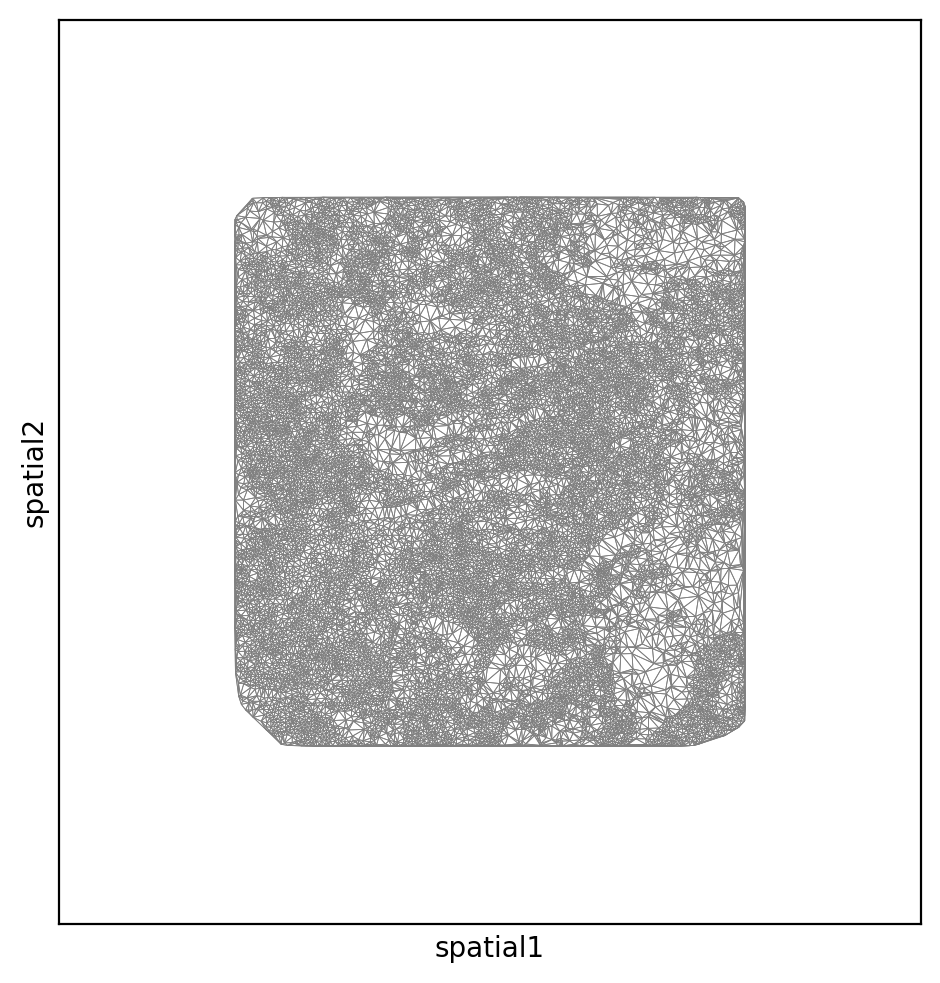

In [31]:
sq.pl.spatial_scatter(
    nmc, 
    img=None, 
    size=2500,
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['sample_1']
    )

In [32]:
import cellcharter as cc
cc.gr.remove_long_links(nmc)

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


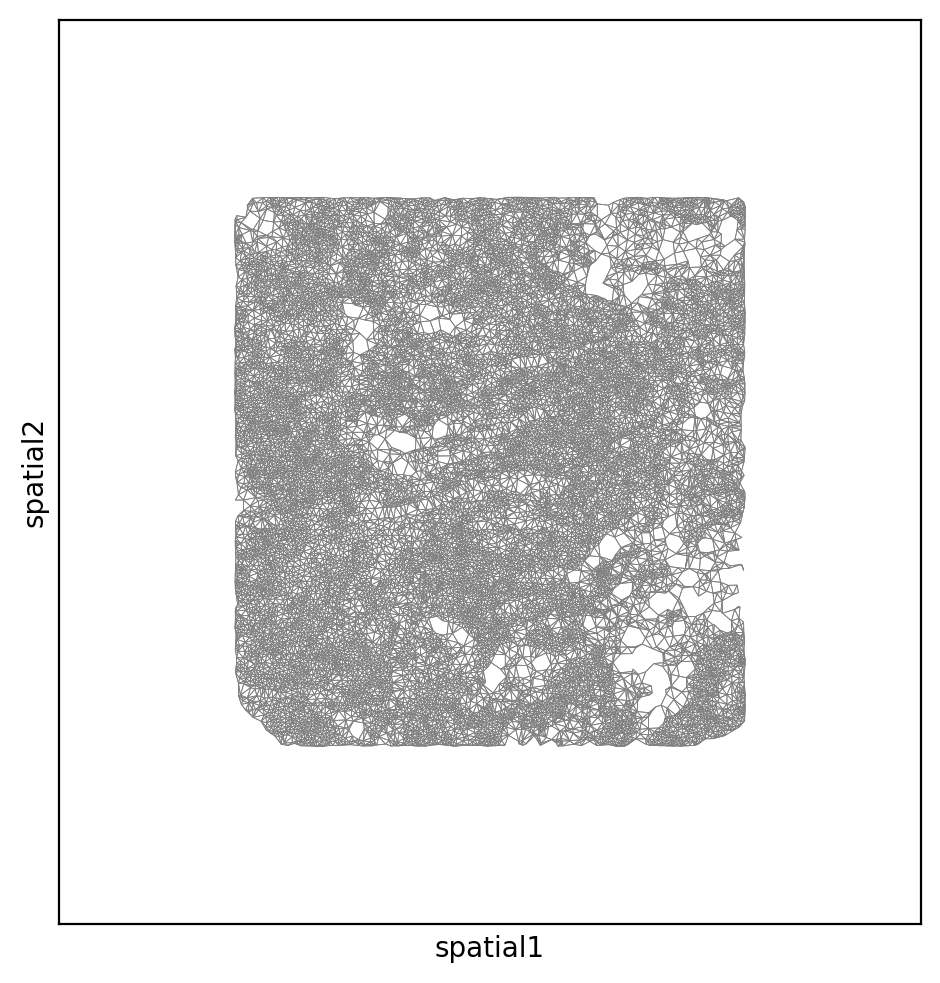

In [33]:
sq.pl.spatial_scatter(
    nmc, 
    img=None, 
    size=2500,
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['sample_1']
    )

In [34]:
cc.gr.aggregate_neighbors(nmc, n_layers=3)

100%|██████████| 4/4 [00:00<00:00, 101.87it/s]


In [35]:
model_params = {
    'random_state': 42,
    'trainer_params': {
        'accelerator':'cpu',
        'enable_progress_bar': False
        },
    }

autok = cc.tl.ClusterAutoK(n_clusters=(4,20), model_class=cc.tl.GaussianMixture, 
                           model_params=model_params, 
                           max_runs=5)

In [36]:
autok.fit(nmc, use_rep='X_cellcharter')

Iteration 1/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU avail

Iteration 2/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU ava

Iteration 3/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU avail

Iteration 4/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU avail

Iteration 5/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU avail

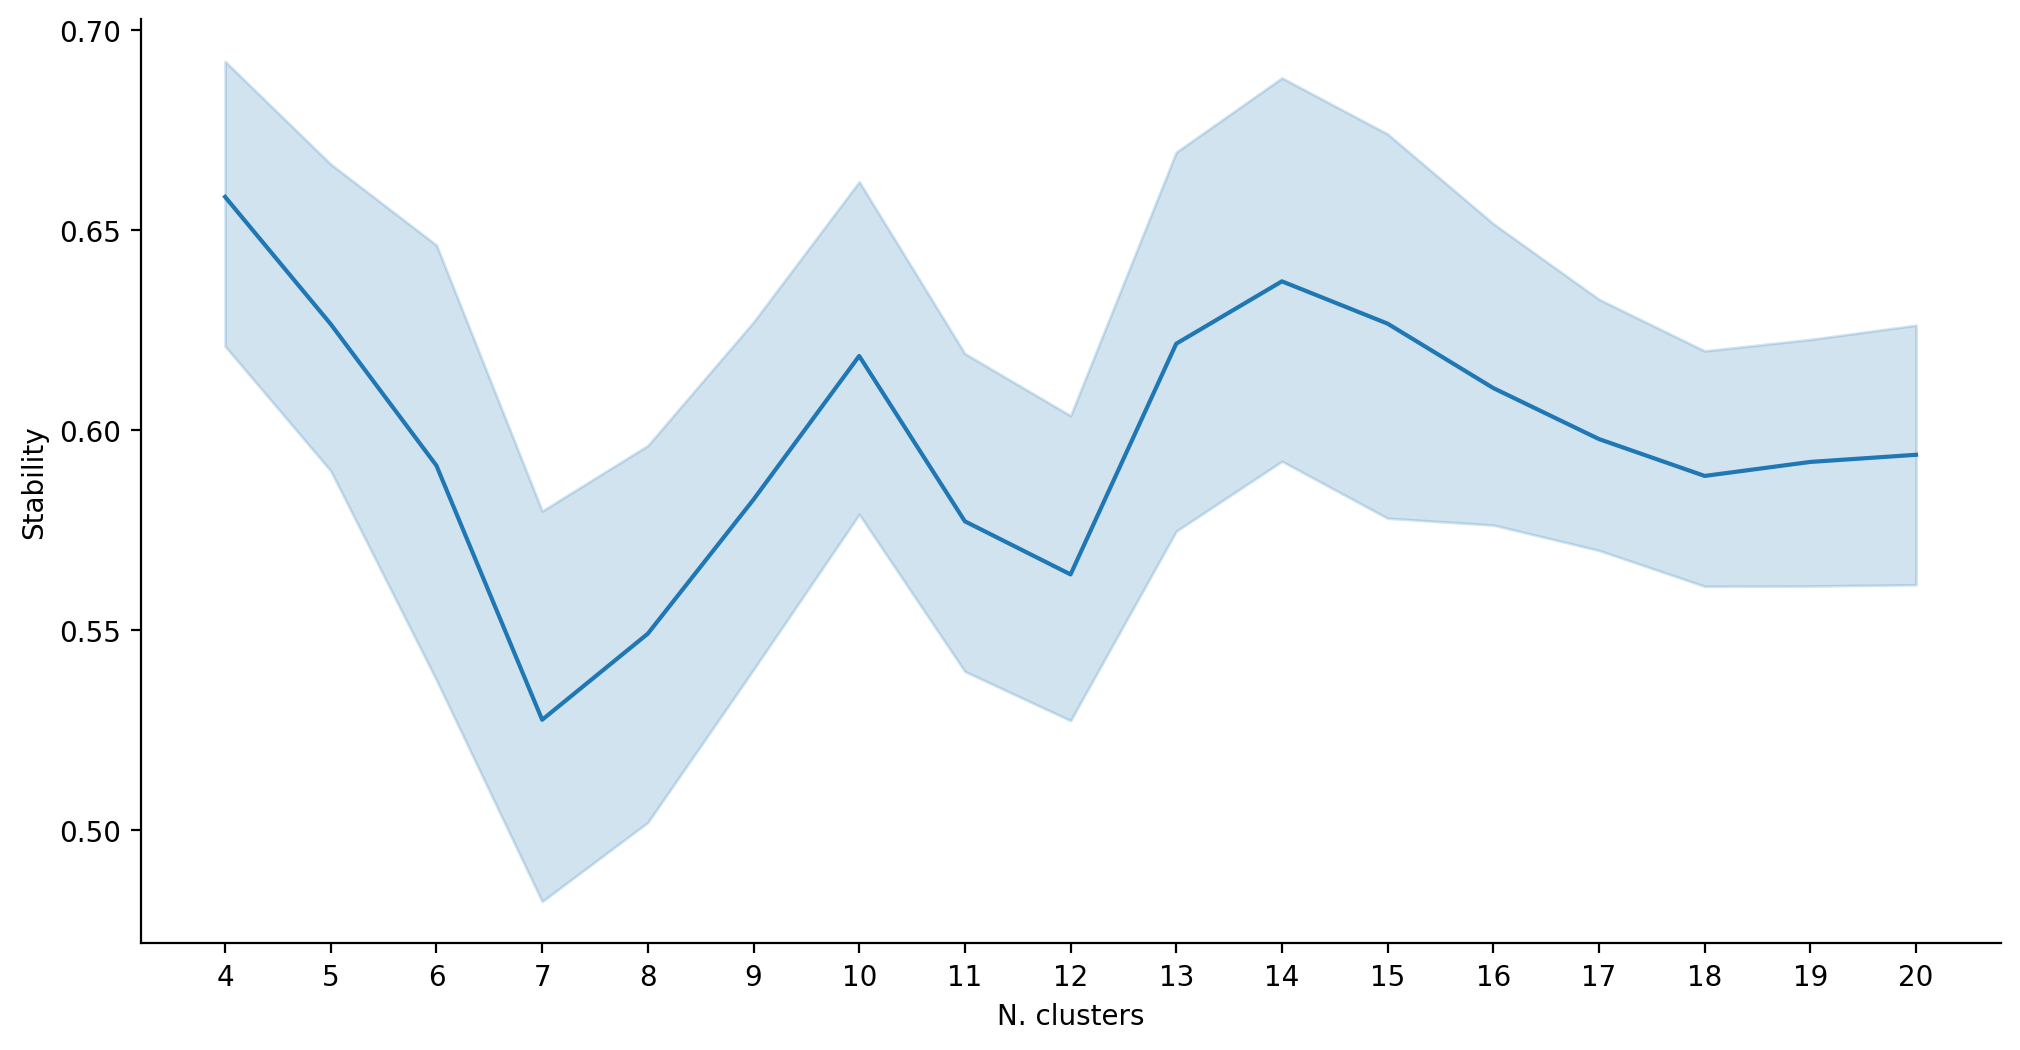

In [37]:
ax = cc.pl.autok_stability(autok, return_ax=True)
ax.figure.set_size_inches(12, 6)  

In [38]:
gmm = cc.tl.Cluster(
    n_clusters=4, 
    random_state=12345,
    # If running on GPU
    #trainer_params=dict(accelerator='gpu', devices=1)
)

In [39]:
gmm.fit(nmc, use_rep='X_cellcharter')
nmc.obs['spatial_cluster'] = gmm.predict(nmc, use_rep='X_cellcharter')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=7` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/torchgmm/bayes/core/normal.py:26: UserWarning: The operator 'aten::linalg_cholesky_ex.L' is not currently supported on the MPS backend and 

Epoch 133: 100%|██████████| 1/1 [00:00<00:00, 39.73it/s, nll=-303.] 


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 113.63it/s]


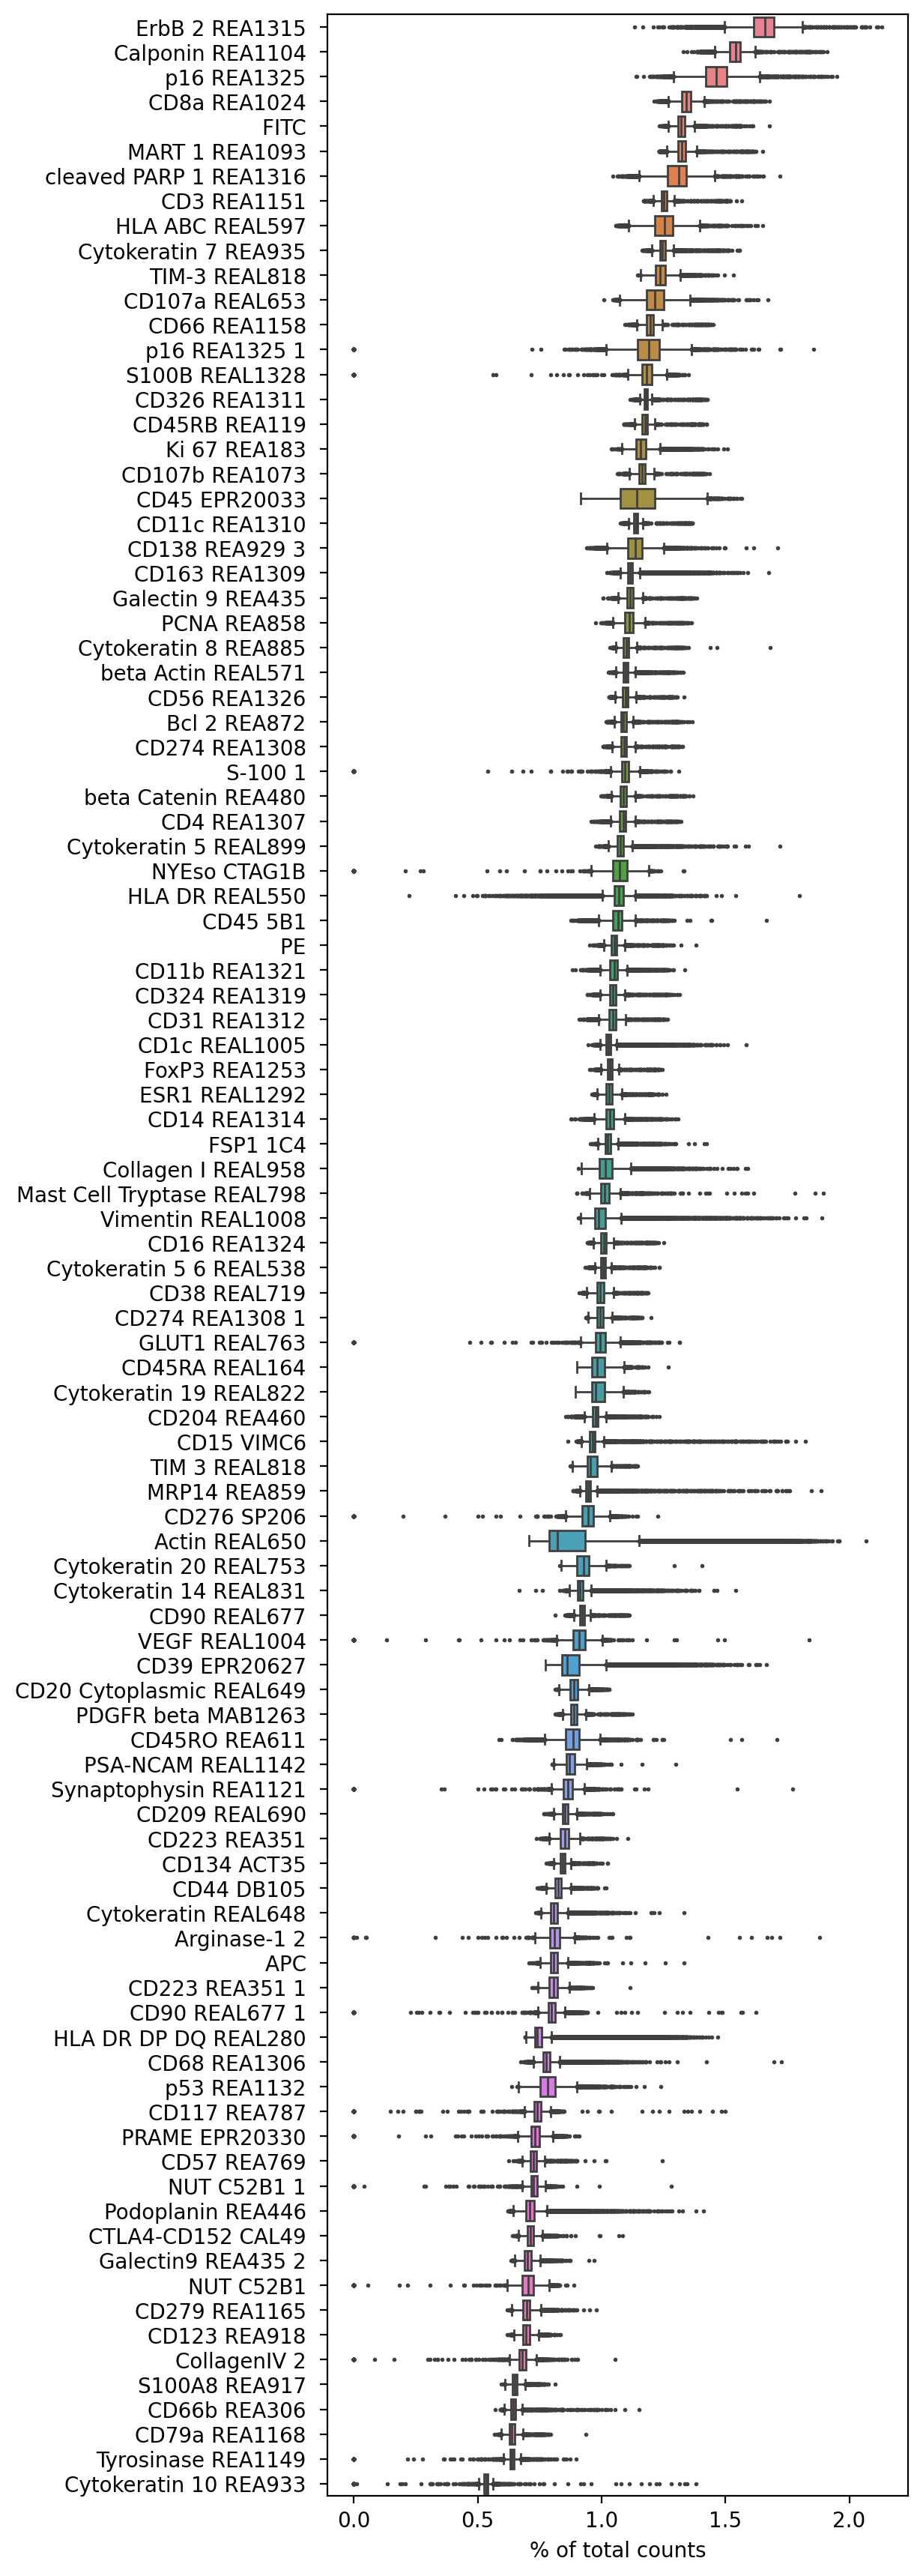

In [45]:
#quality control check the nmc data plotting
#plot all the genes mean expression
sc.pl.highest_expr_genes(nmc.raw, n_top=100)


In [58]:
nmc.var

""
Actin REAL650
APC
Arginase-1 2
Bcl 2 REA872
beta Actin REAL571
...
TIM-3 REAL818
Tyrosinase REA1149
VEGF REAL1004
Vimentin REAL1008


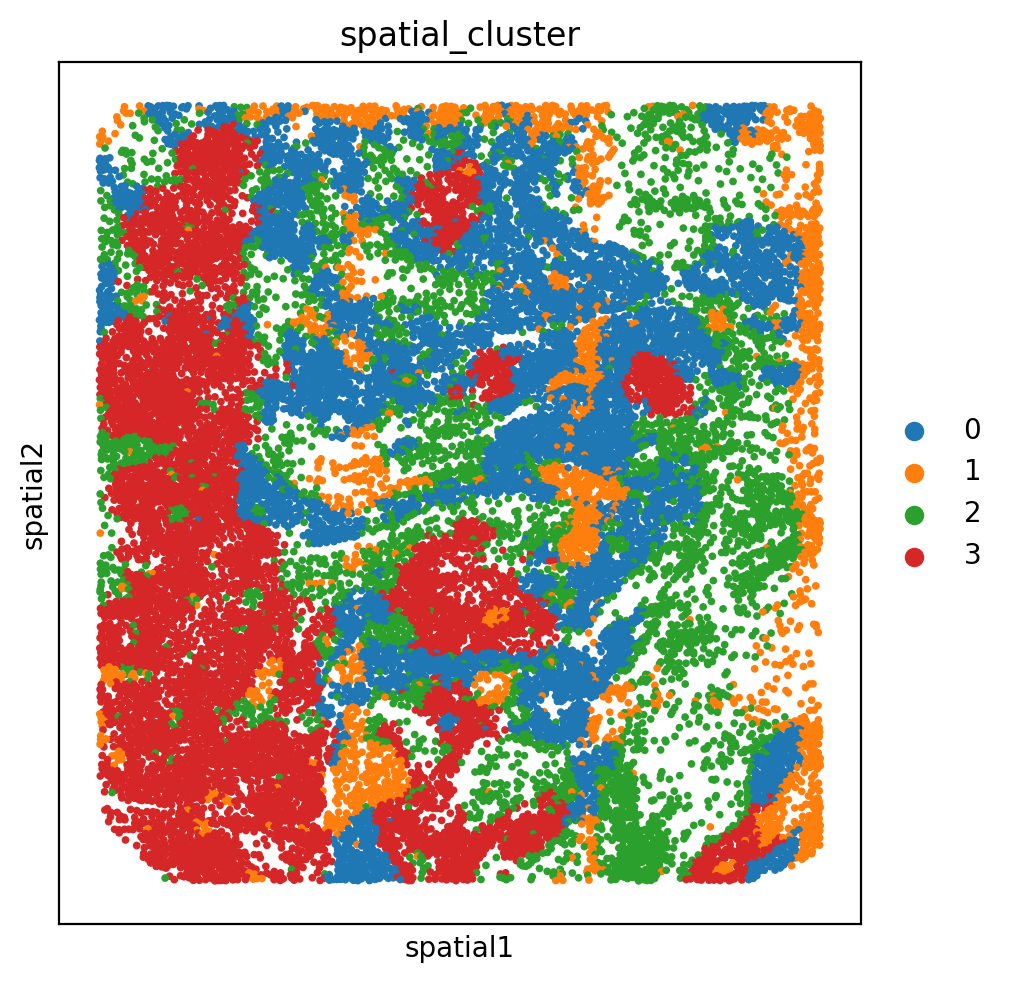

In [40]:
sq.pl.spatial_scatter(
    nmc, 
    color='spatial_cluster', 
    img=None, 
    size=50,
    ncols=1,
    library_id=['sample_1'],
)

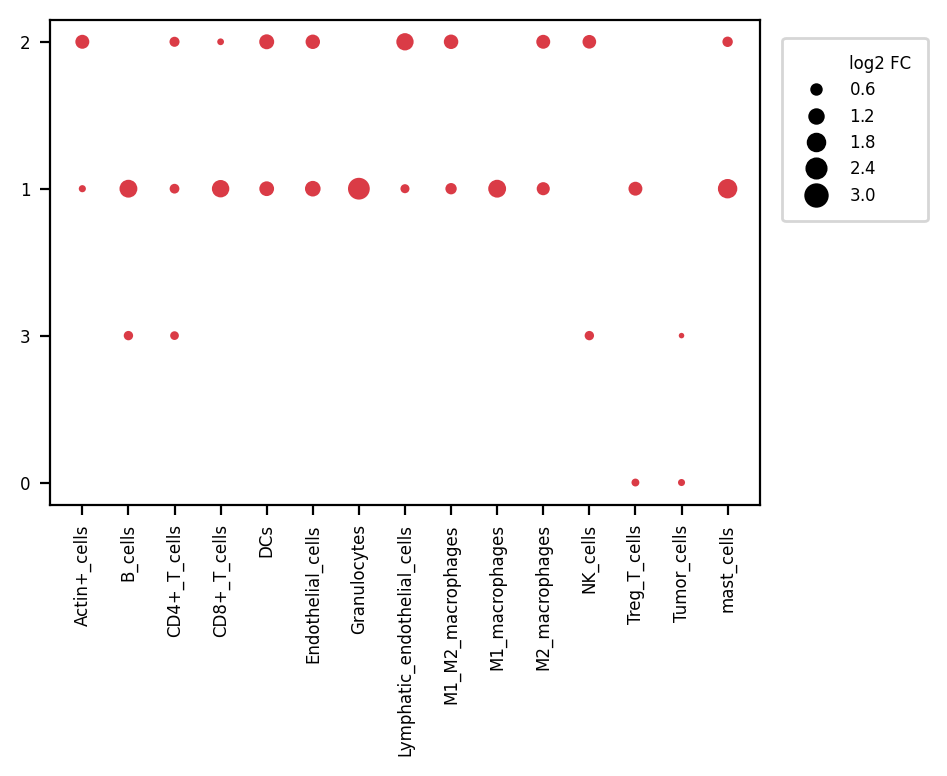

In [41]:
cc.gr.enrichment(nmc, group_key='spatial_cluster', label_key='cell_type')
cc.pl.enrichment(nmc, group_key='spatial_cluster', label_key='cell_type', figsize=(4,4), fontsize=6, dot_scale=1)

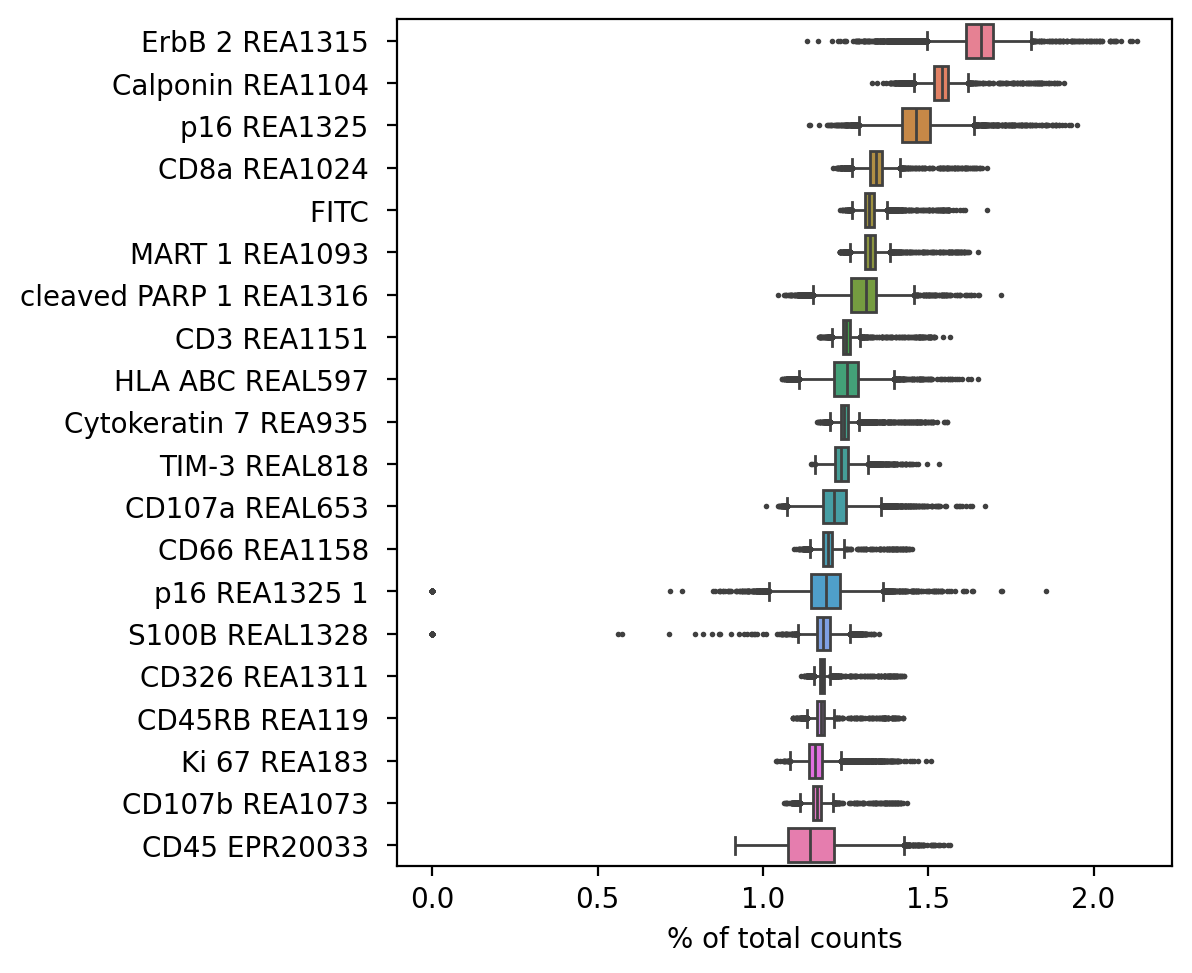

In [52]:
#i wanna take a look at the raw data in nmc and the boxplots of expression of all markers
#plot nmc.raw as boxplots, with the x-axis being the genes and the y-axis is the expression
#of the genes
sc.pl.highest_expr_genes(nmc.raw, n_top=20)


# Expected threshold values:  extract from annotations.


In [16]:
celesta_pmap=pd.read_csv(data_dir / 'celesta_pmap.csv')
celesta_pmap.rename(columns={'Unnamed: 0':'cell_label'},inplace=True)
celesta_pmap_filt=celesta_pmap.loc[celesta_pmap['cell_label'].isin(df_macsiq_filt['cell_id'].unique())]
celesta_pmap_filt.head()

,cell_label,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
3,4,0.083916,0.386513,0.108594,0.334409,0.564205,0.769635,0.505292,0.189973,0.584317,0.237574,0.162406,0.097911,0.277741,0.269353,0.062747,0.199930
4,5,0.119430,0.426636,0.547941,0.450508,0.333117,0.407027,0.342674,0.282912,0.562413,0.301322,0.634949,0.035902,0.755003,0.504743,0.253593,0.721325
6,7,0.328242,0.974179,0.520232,0.320566,0.335357,0.179162,0.129410,0.470849,0.717932,0.351785,0.447661,0.877506,0.322087,0.383449,0.607736,0.303209
7,8,0.582006,0.985430,0.419617,0.339774,0.233130,0.426783,0.207260,0.195632,0.757836,0.347979,0.649713,0.549784,0.631159,0.480559,0.520031,0.452169
8,9,0.388851,0.501281,0.380254,0.386383,0.508643,0.354656,0.402420,0.388531,0.728094,0.364805,0.812279,0.954045,0.511736,0.670779,0.350240,0.399576


In [18]:
markers_list=celesta_pmap_filt.columns[1::].tolist()
print("Markers in celesta map:")
for m in markers_list:
    print(m)

Markers in celesta map:
CD3
CD66b
Cytokeratin
Mast_Cell_Tryptase
Actin
Myosin_Smooth_Muscle
CD20
CD56
CD45RO
CD138
CD68
CD14
CD8
CD4
FOXP3
CD31


In [78]:
min_prob={}
index=[]
for marker in markers_list:
    
    min_prob[marker]=[]
    
for cell_type,labels in type_label_map.items():
    
    for marker in markers_list:
        min_prob[marker].append(celesta_pmap_filt.loc[celesta_pmap_filt['cell_label'].isin(labels),marker].min())
    
    index.append(cell_type)
    
min_prob_df=pd.DataFrame(min_prob,index=index) 
min_prob_df.head(100)

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
Fibroblasts,0.000000,0.000241,0.071386,0.287350,0.207287,0.571988,0.091585,0.000000,0.046015,0.075899,0.073706,0.003258,0.187542,0.165740,0.000000,0.051882
Macrophages,0.000000,0.000147,0.062623,0.146008,0.000000,0.083971,0.039690,0.000000,0.064621,0.119244,0.459933,0.010575,0.240301,0.228929,0.000000,0.034329
Granulocytes,0.000000,0.971716,0.092302,0.223949,0.000000,0.049993,0.048226,0.000000,0.056528,0.077620,0.155484,0.013335,0.213161,0.140869,0.000000,0.052105
plasma,0.170203,0.006202,0.125065,0.244714,0.093681,0.192055,0.163852,0.090704,0.126399,0.834657,0.166817,0.012090,0.235237,0.264825,0.091470,0.140950
Cancer,0.000000,0.000761,0.782936,0.021938,0.000000,0.022518,0.000000,0.000000,0.079299,0.149682,0.020524,0.000547,0.000000,0.306039,0.000000,0.000000
DN T-cells,0.850020,0.003278,0.082394,0.238136,0.054273,0.084546,0.108913,0.167311,0.392792,0.170115,0.046222,0.001315,0.236032,0.217020,0.366679,0.072760
Endothelial,0.000000,0.000000,0.088247,0.042469,0.000000,0.050202,0.074767,0.000000,0.139405,0.000000,0.044985,0.000000,0.000000,0.089086,0.000000,0.956520
T-cells,0.851585,0.012041,0.105427,0.273658,0.069514,0.115281,0.117894,0.338421,0.467501,0.246732,0.105014,0.038358,0.281463,0.200145,0.414033,0.081450
non-Treg CD4,0.850339,0.001123,0.086583,0.214190,0.065037,0.070071,0.035419,0.008232,0.403867,0.191215,0.064434,0.008119,0.190345,0.597707,0.361358,0.046342
CD8 T-cells,0.850252,0.001221,0.074907,0.267871,0.035651,0.075304,0.081985,0.064328,0.260246,0.228028,0.101342,0.010267,0.870167,0.205094,0.258808,0.103251


In [79]:
signat_matrix_mod=signat_matrix.set_index('Unnamed: 0')
signat_matrix_mod.head(100)

,Lineage_level,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
Unnamed: 0,,,,,,,,,,,,,,,,,
T-cells,1_0_1,1.0,0,NaN,0,0.0,0.0,0,0.0,1,0,0,0,NaN,NaN,NaN,0.0
Granulocytes,1_0_2,0.0,1,NaN,0,0.0,0.0,0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
Cancer,1_0_3,0.0,0,1.0,0,0.0,0.0,0,NaN,0,0,0,0,0.0,0.0,0.0,0.0
Mast cells,1_0_4,0.0,0,0.0,1,0.0,0.0,0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
Macrophages,1_0_5,0.0,0,0.0,0,0.0,0.0,0,0.0,0,0,1,1,0.0,0.0,0.0,0.0
Fibroblasts,1_0_6,0.0,0,0.0,0,1.0,1.0,0,0.0,0,0,0,0,0.0,0.0,0.0,NaN
B-cells,1_0_7,0.0,0,0.0,0,0.0,0.0,1,0.0,0,0,0,0,0.0,0.0,0.0,0.0
NK,1_0_8,0.0,0,0.0,0,0.0,0.0,0,1.0,1,0,0,0,NaN,NaN,0.0,0.0
plasma,1_0_9,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1,0,0,0.0,0.0,0.0,0.0


In [80]:
threshold_ann_matrix=signat_matrix_mod.iloc[:,1::].mul(min_prob_df)
threshold_ann_matrix.head(100)

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
B-cells,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.889636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
CD4 T-cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD8 T-cells,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.870167,0.000000,0.00000,0.00000
Cancer,0.000000,0.000000,0.782936,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
DN T-cells,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
DP T-cells,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.643979,0.667579,0.00000,0.00000
Endothelial,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.95652
Fibroblasts,0.000000,0.000000,0.000000,0.000000,0.207287,0.571988,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,NaN
Granulocytes,0.000000,0.971716,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
Macrophages,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.459933,0.010575,0.000000,0.000000,0.00000,0.00000


In [81]:
ann_pmap_min={}

for marker in threshold_ann_matrix.columns:
    arr=threshold_ann_matrix[marker].values
    aux=arr[arr>0]
    if len(aux)>0:
        
        ann_pmap_min[marker]=[f'{np.min(aux):.2f}']
    
    else: 
        
        ann_pmap_min[marker]=[f'{0:.2f}']

ann_pmap_min_df=pd.DataFrame(ann_pmap_min)
ann_pmap_min_df.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)   / 'celesta_output' / 'min_ann' / 'thr_input.csv',index=False)

ann_pmap_min_df
        

OSError: Cannot save file into a non-existent directory: '\Users\vp232003\Documents\jupyther_projects\CELESTA\round_analysis_results\round_3\celesta_output\min_ann'

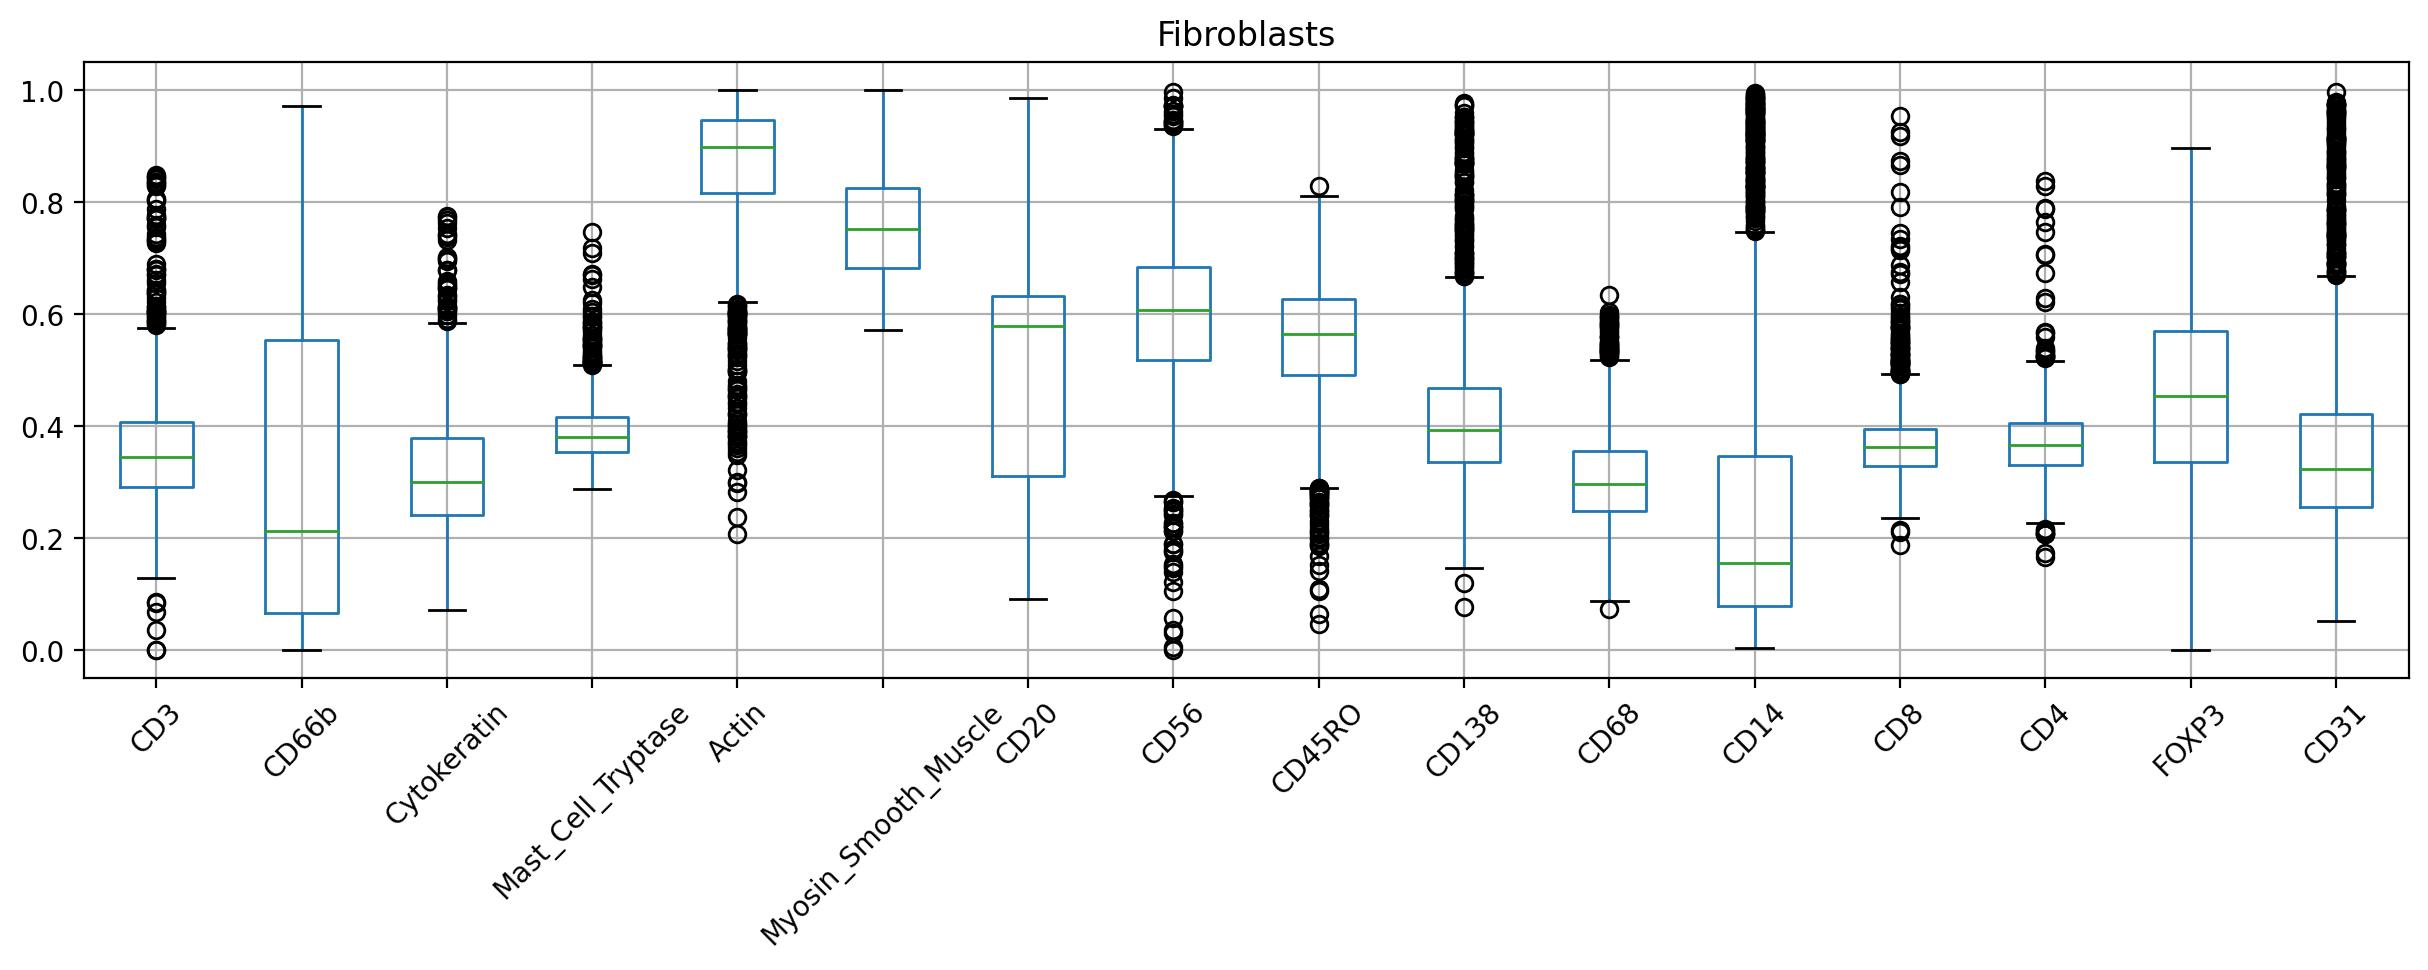

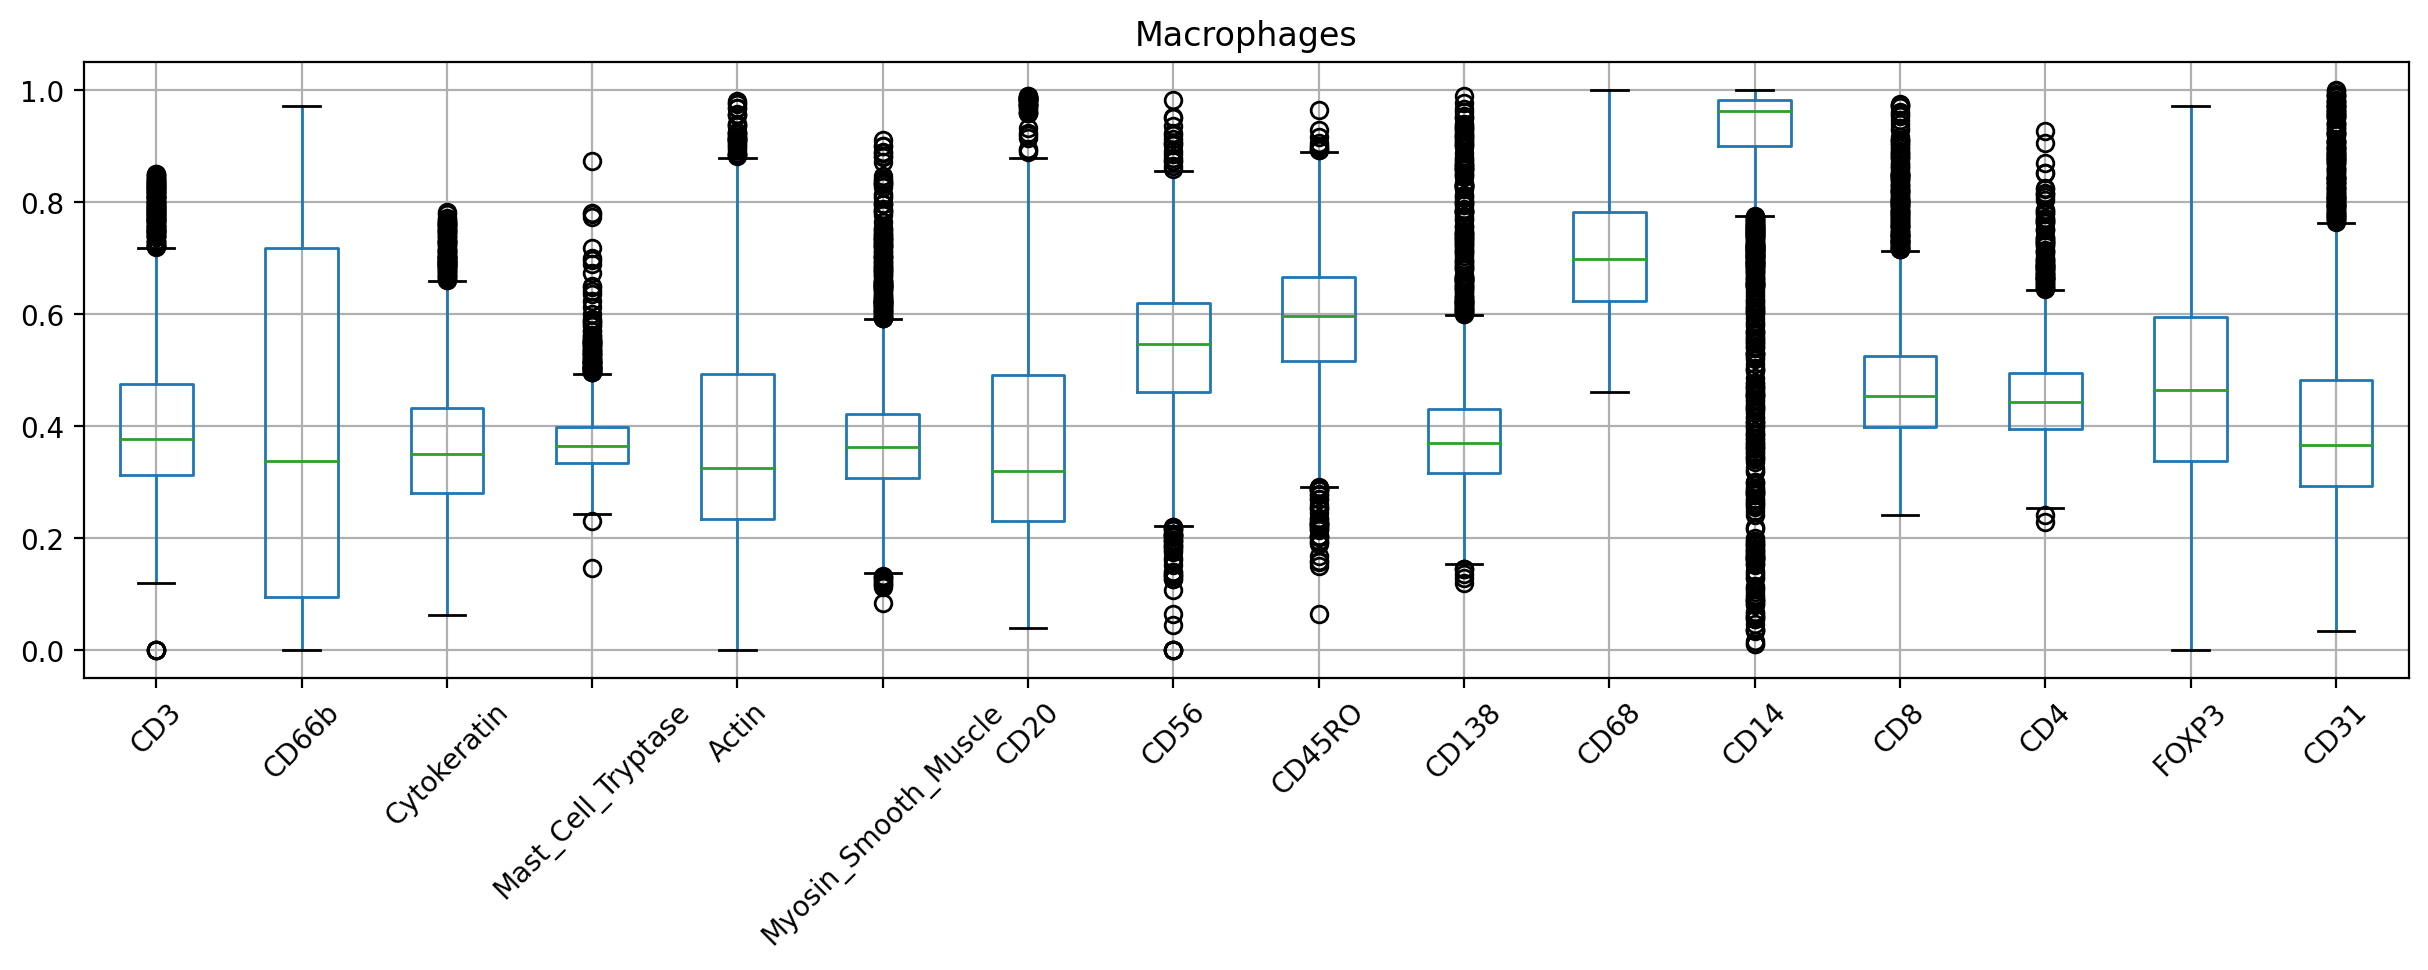

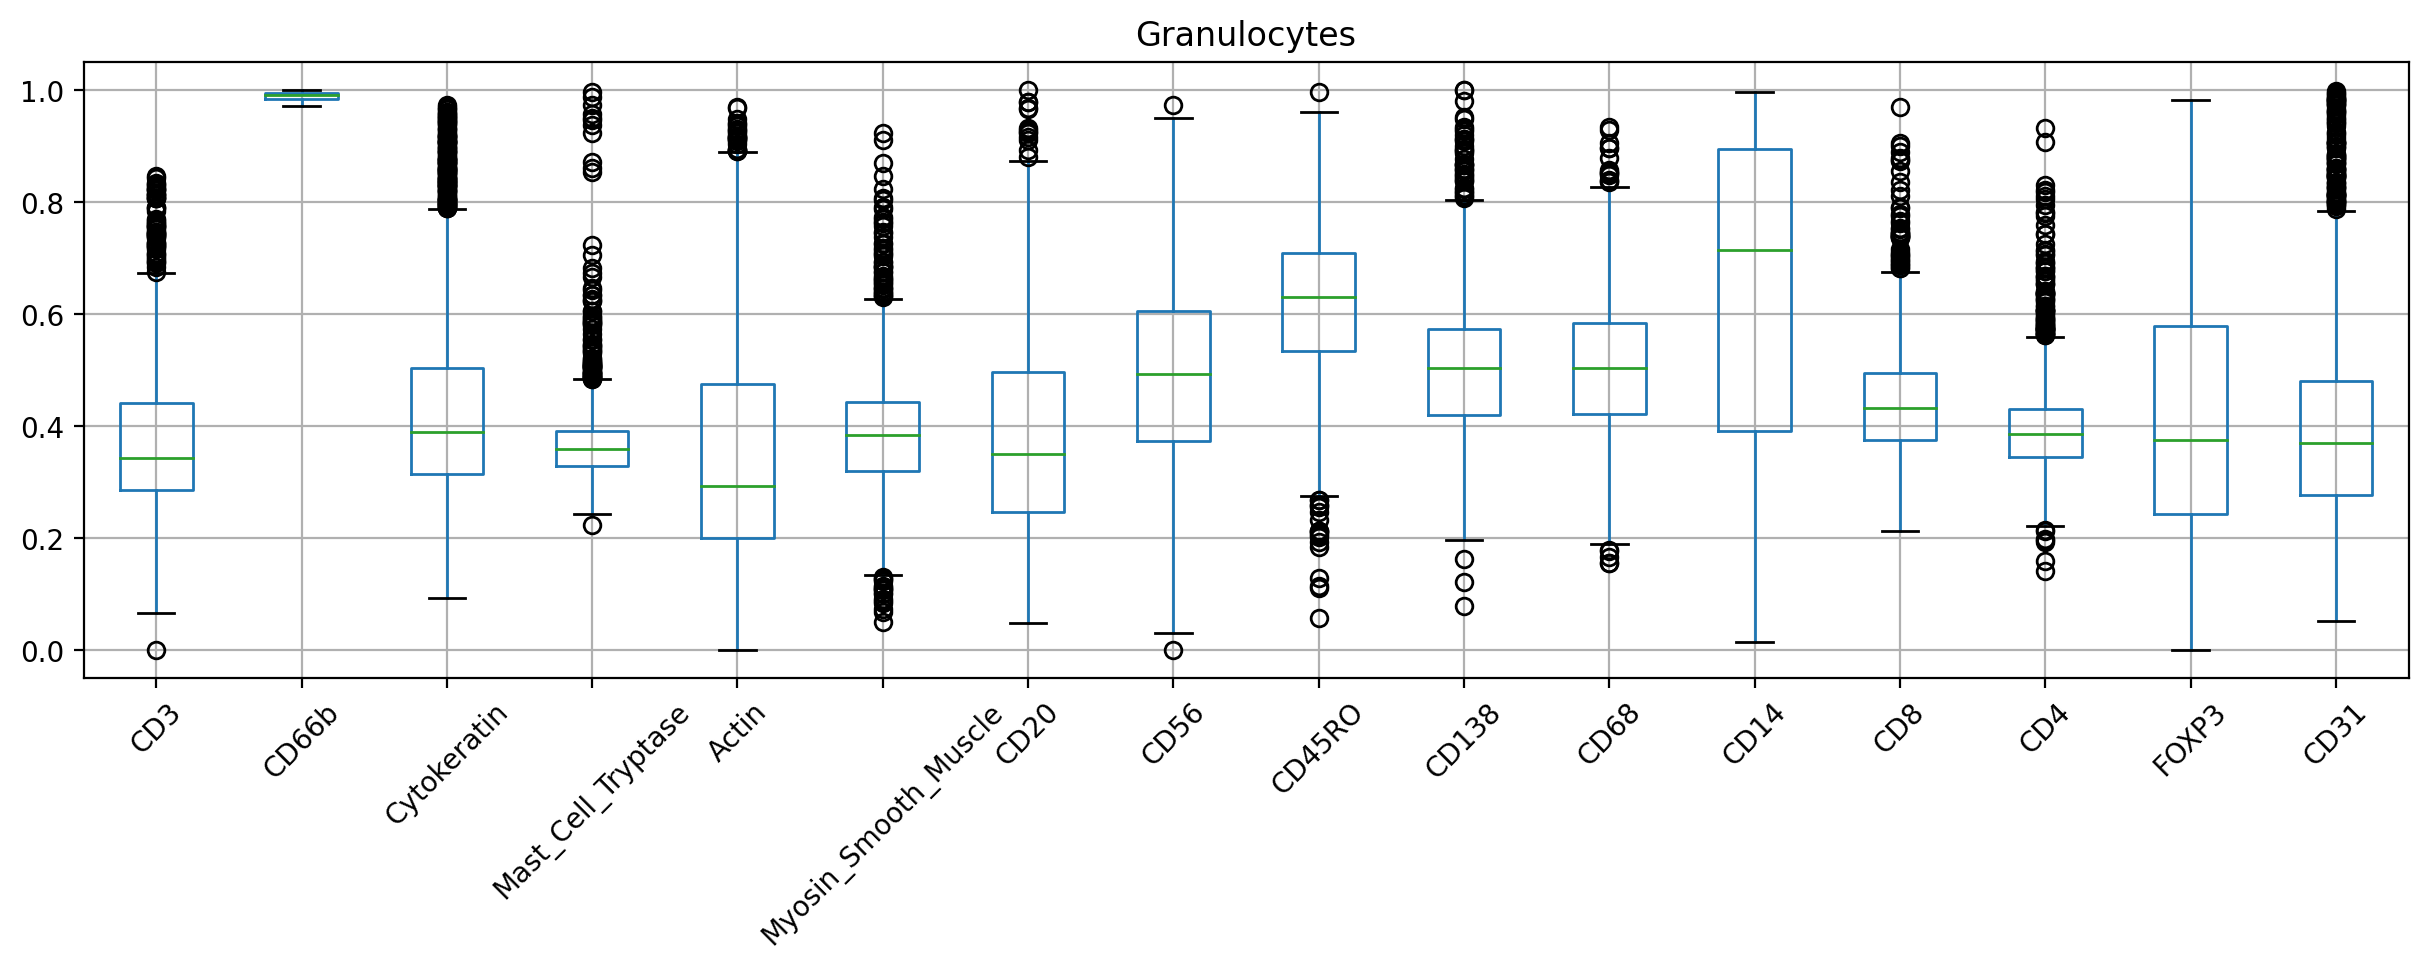

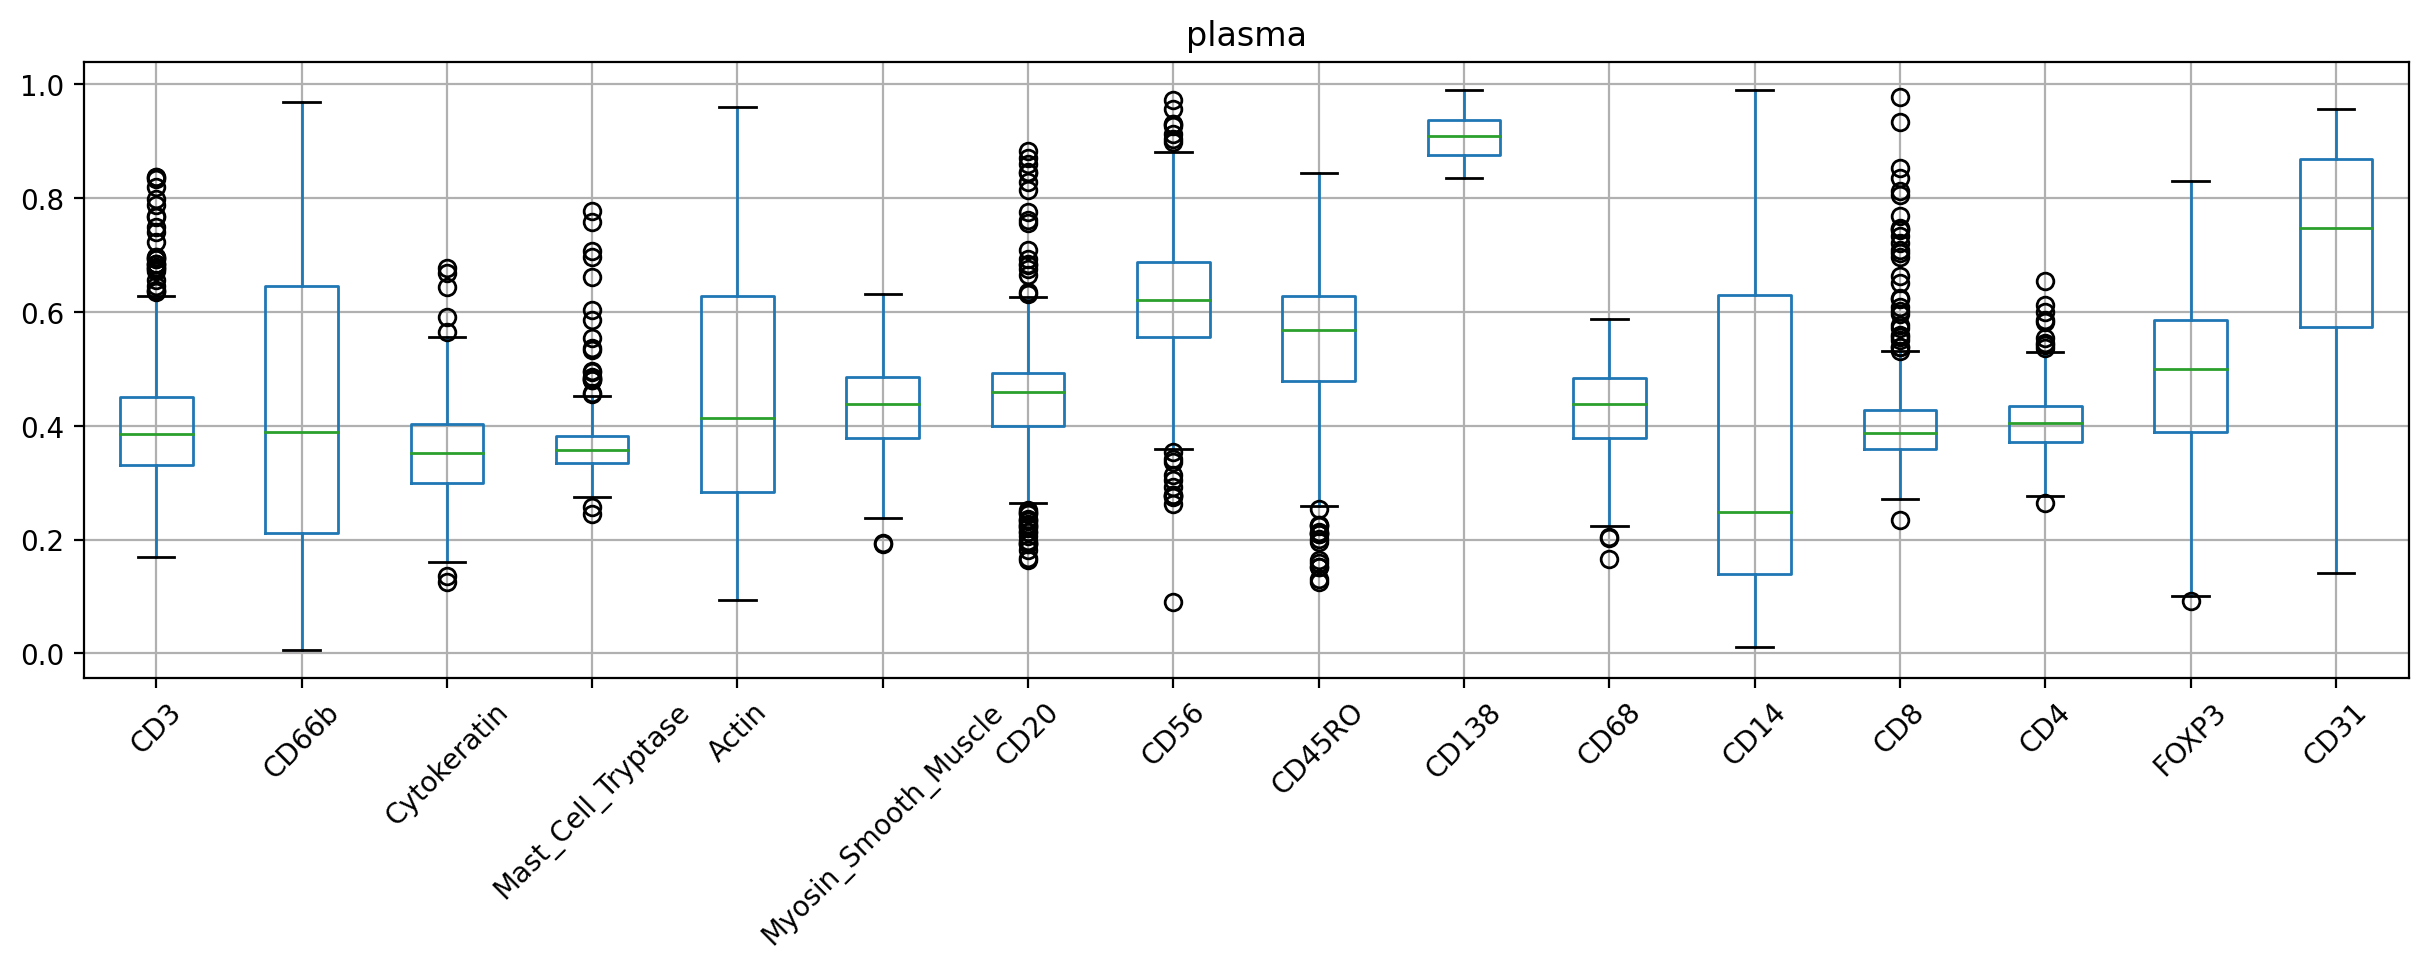

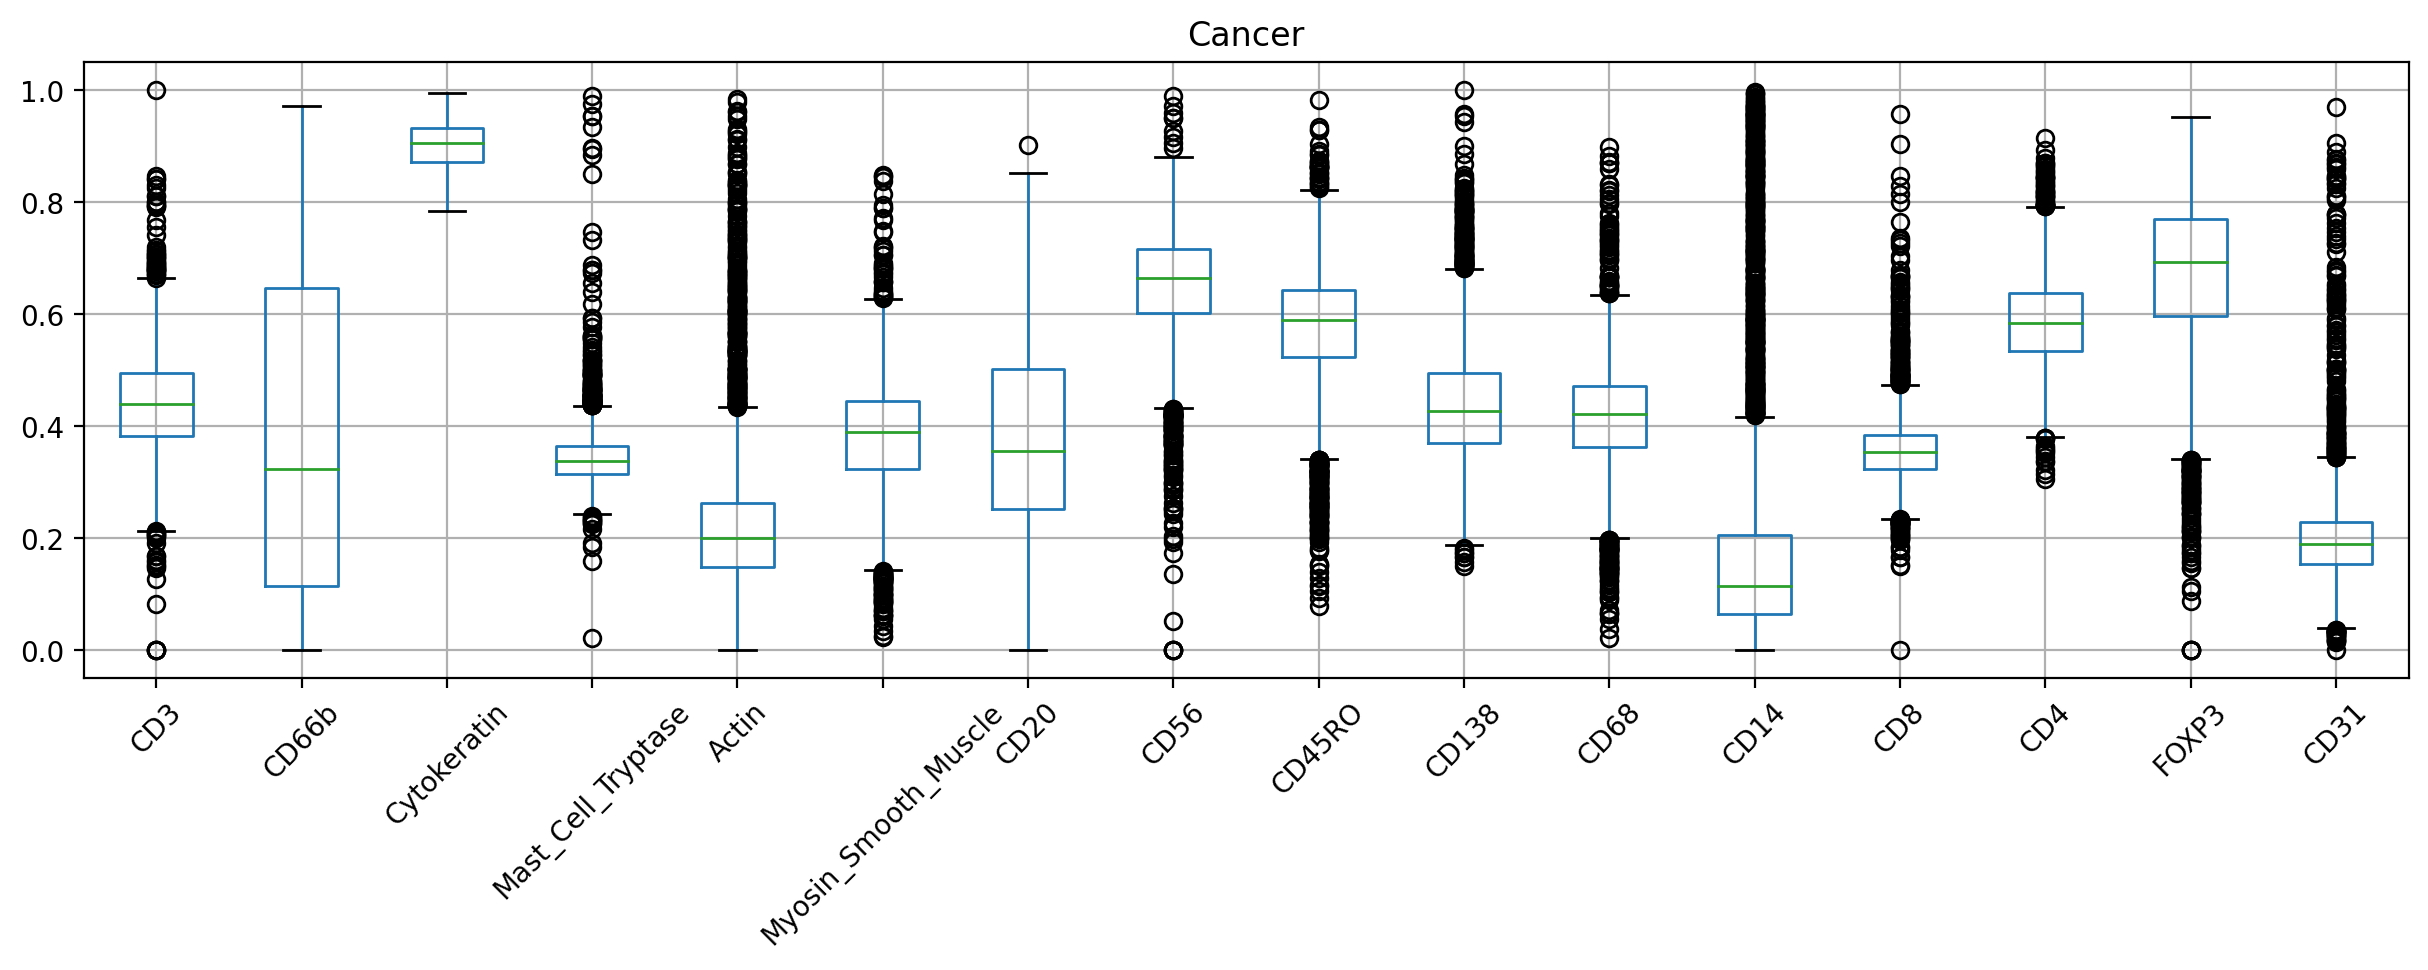

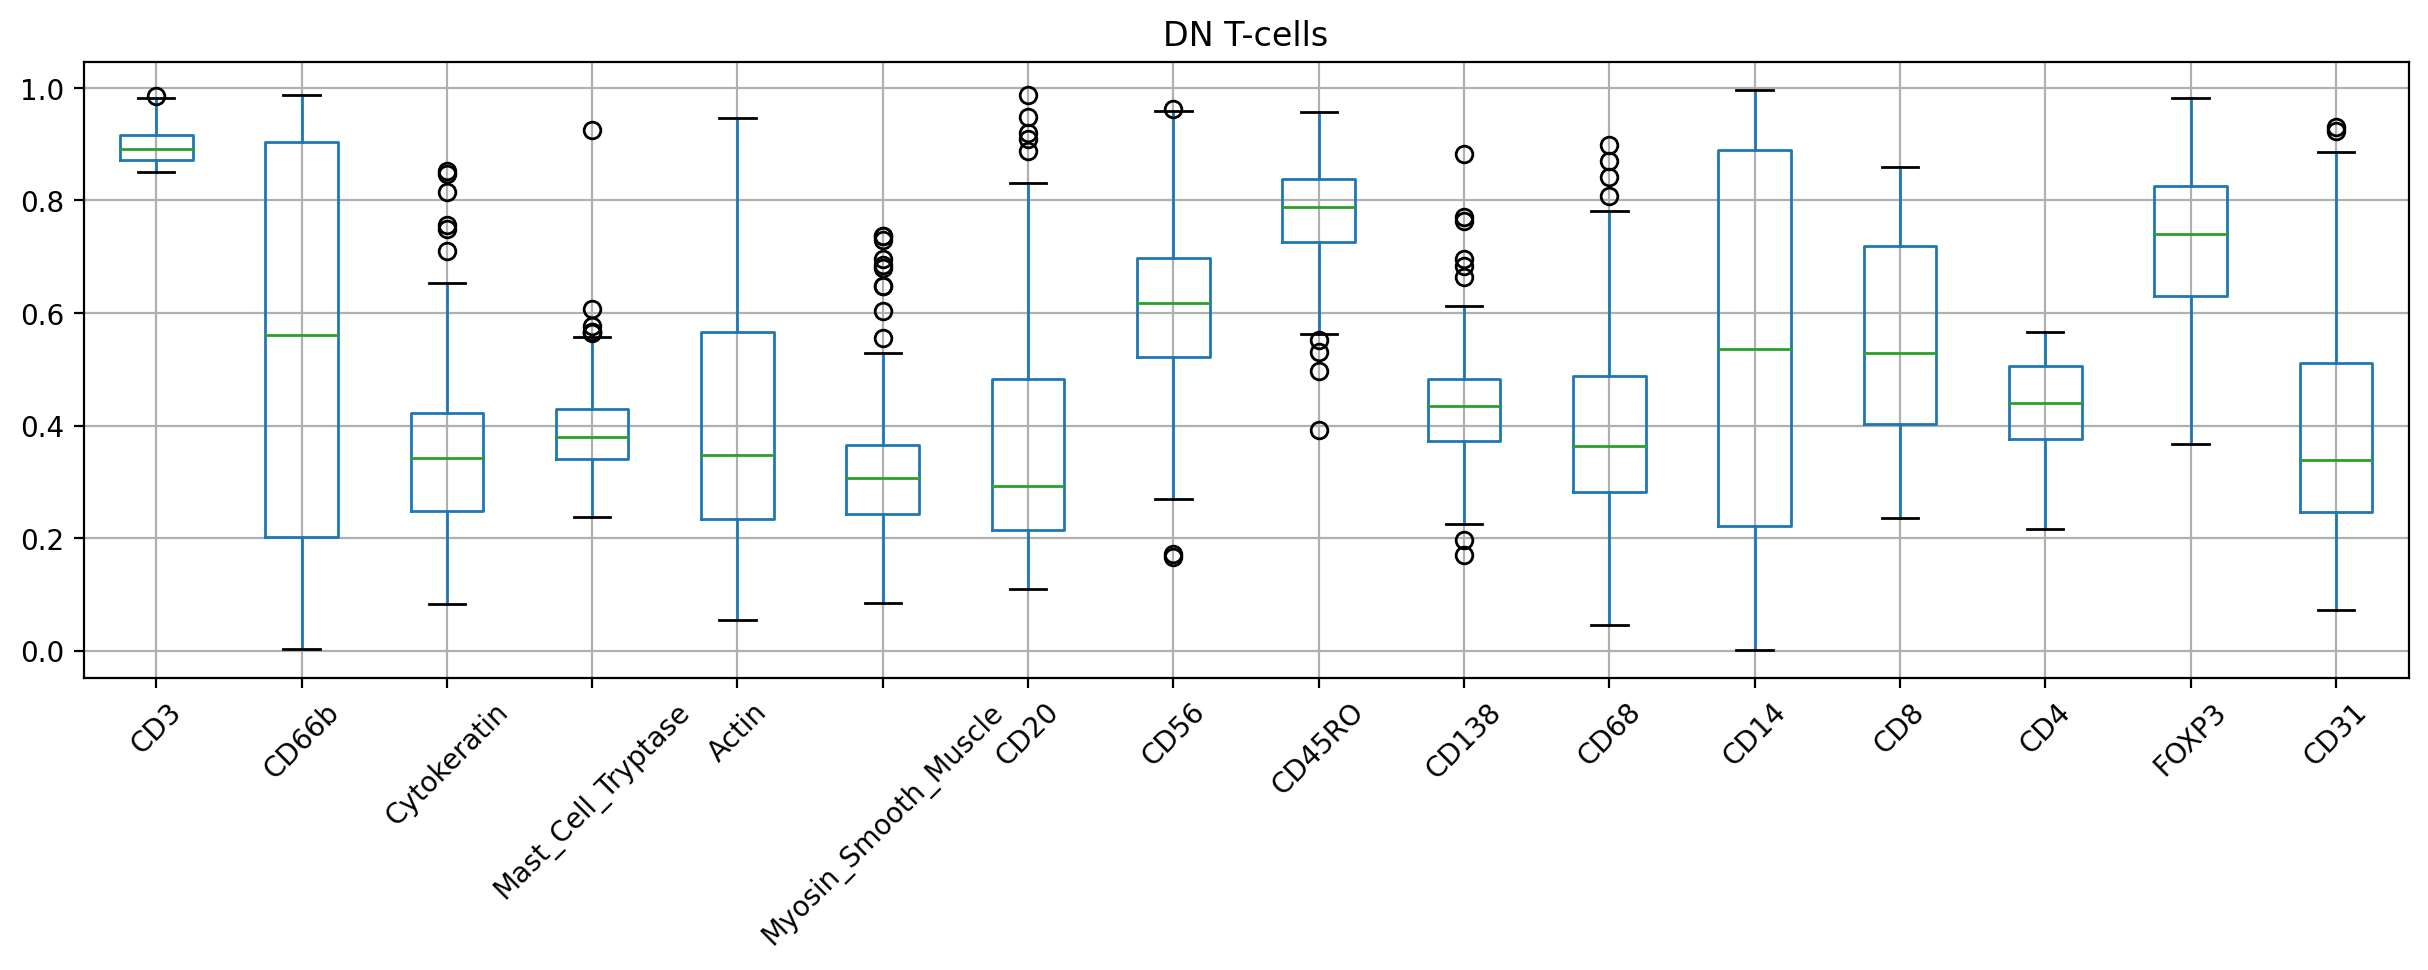

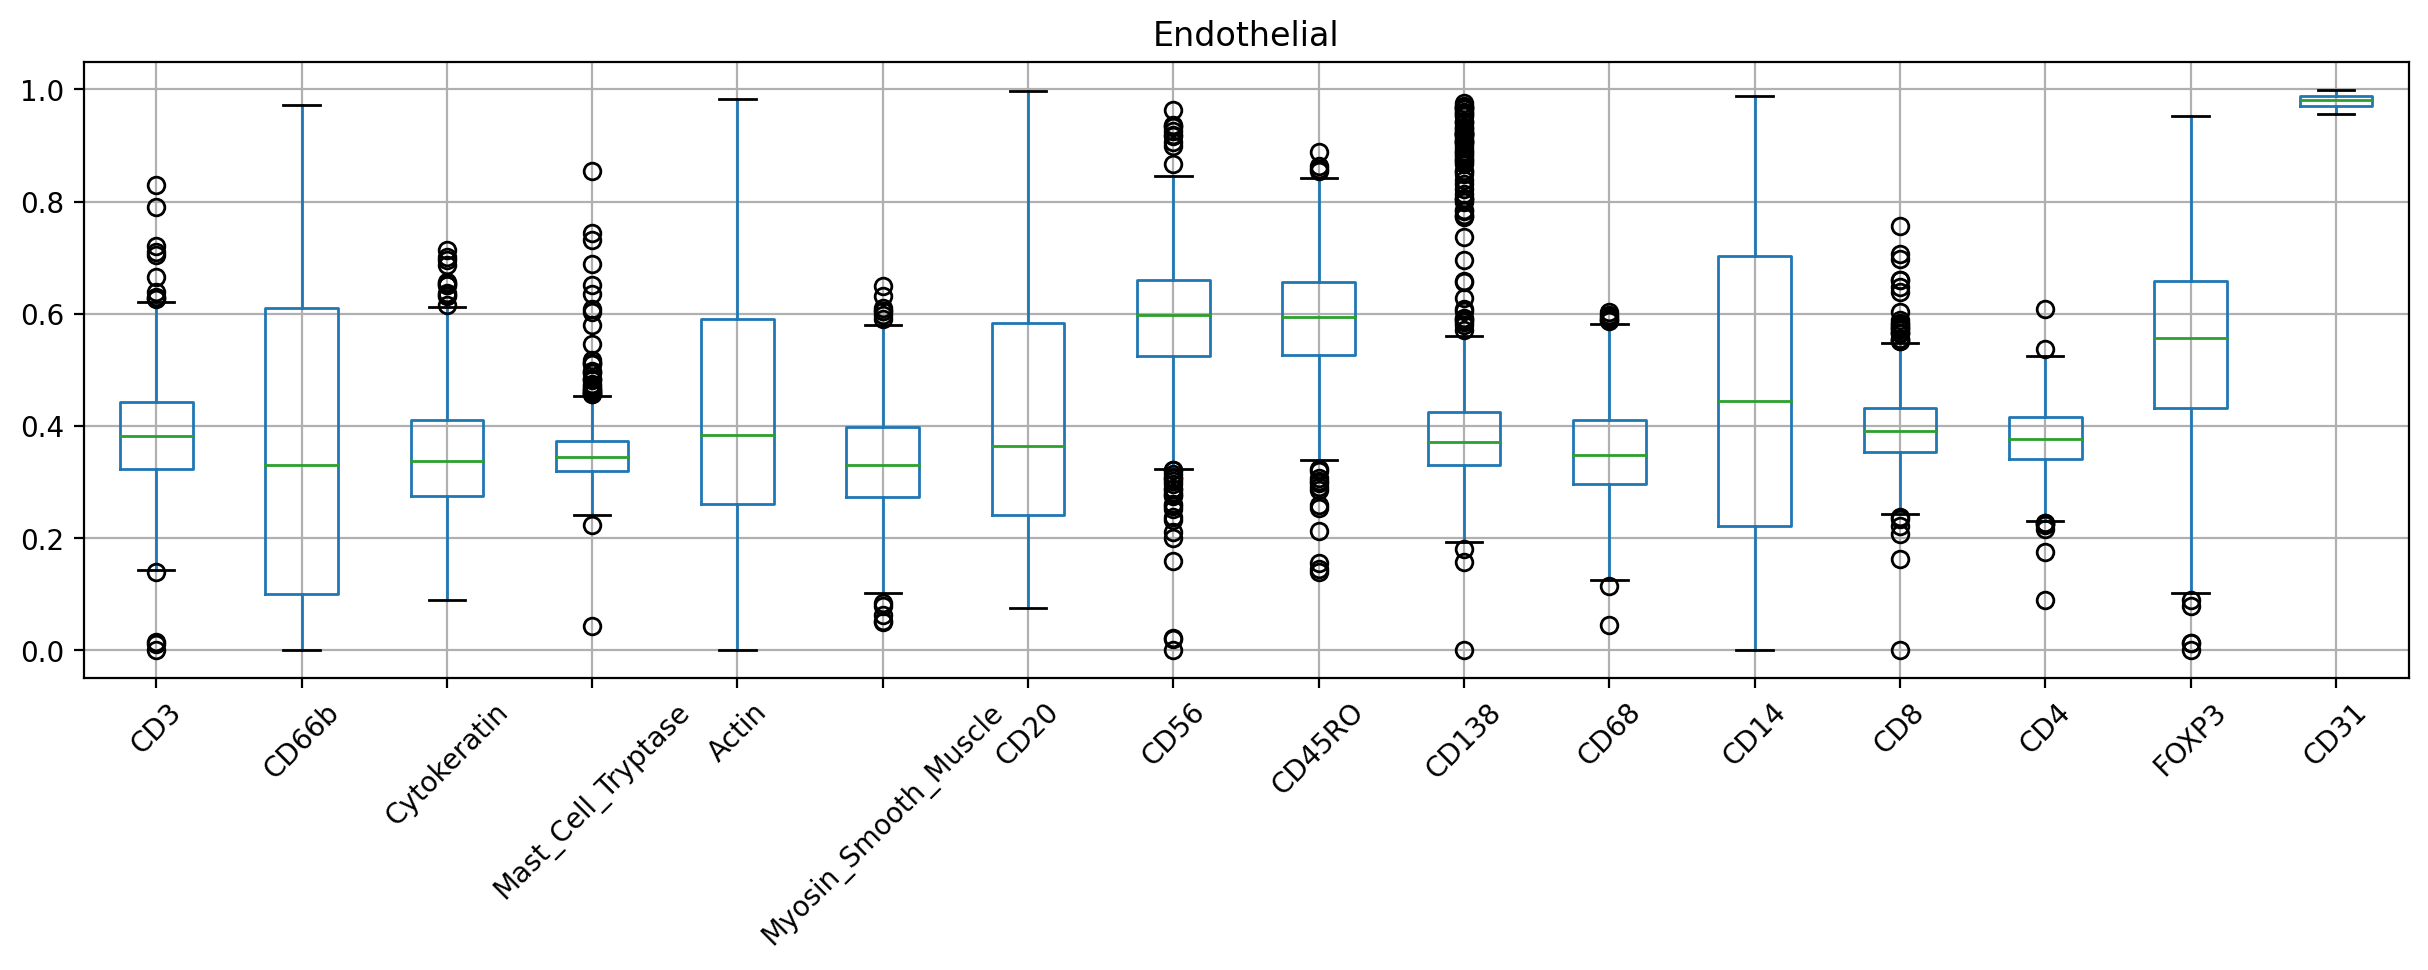

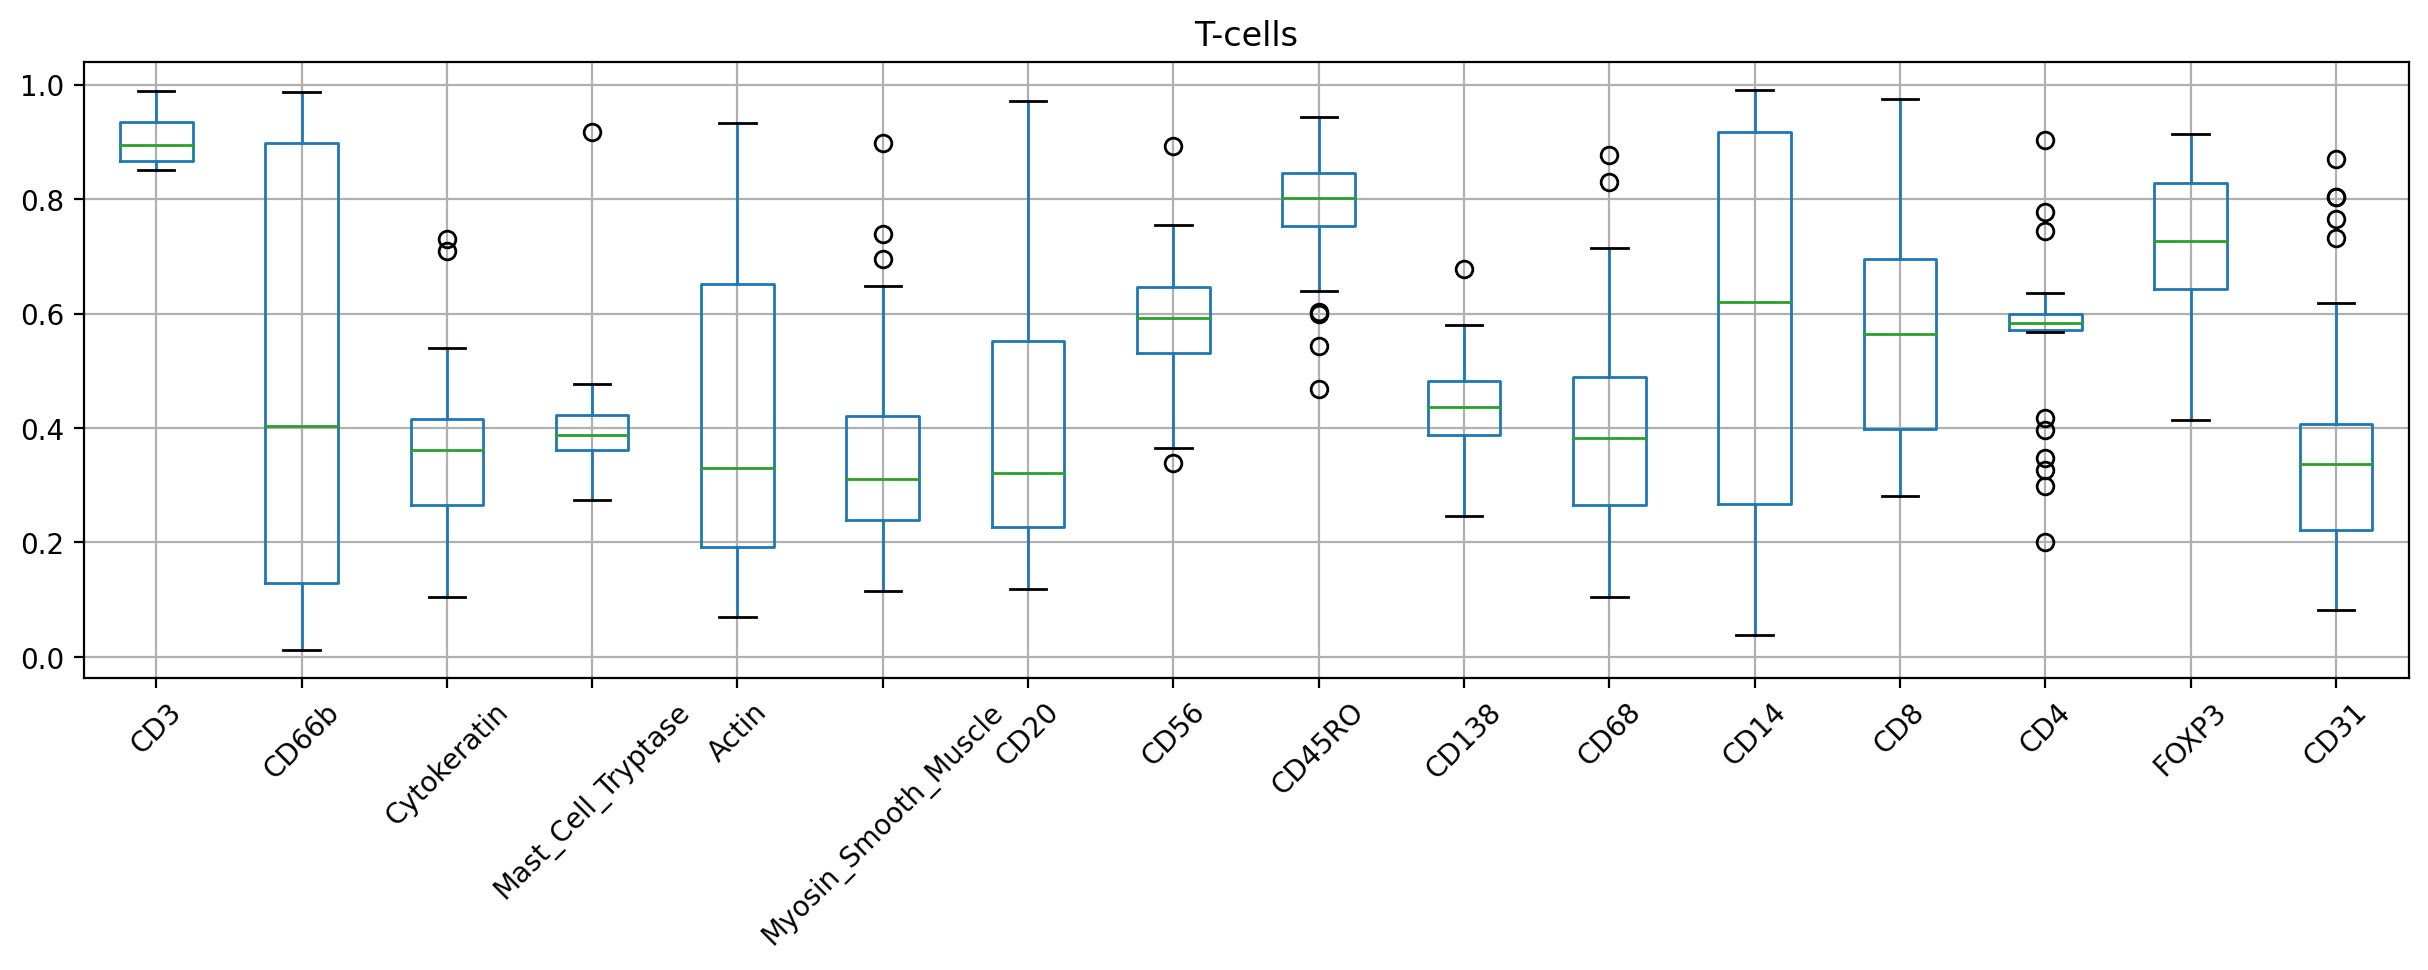

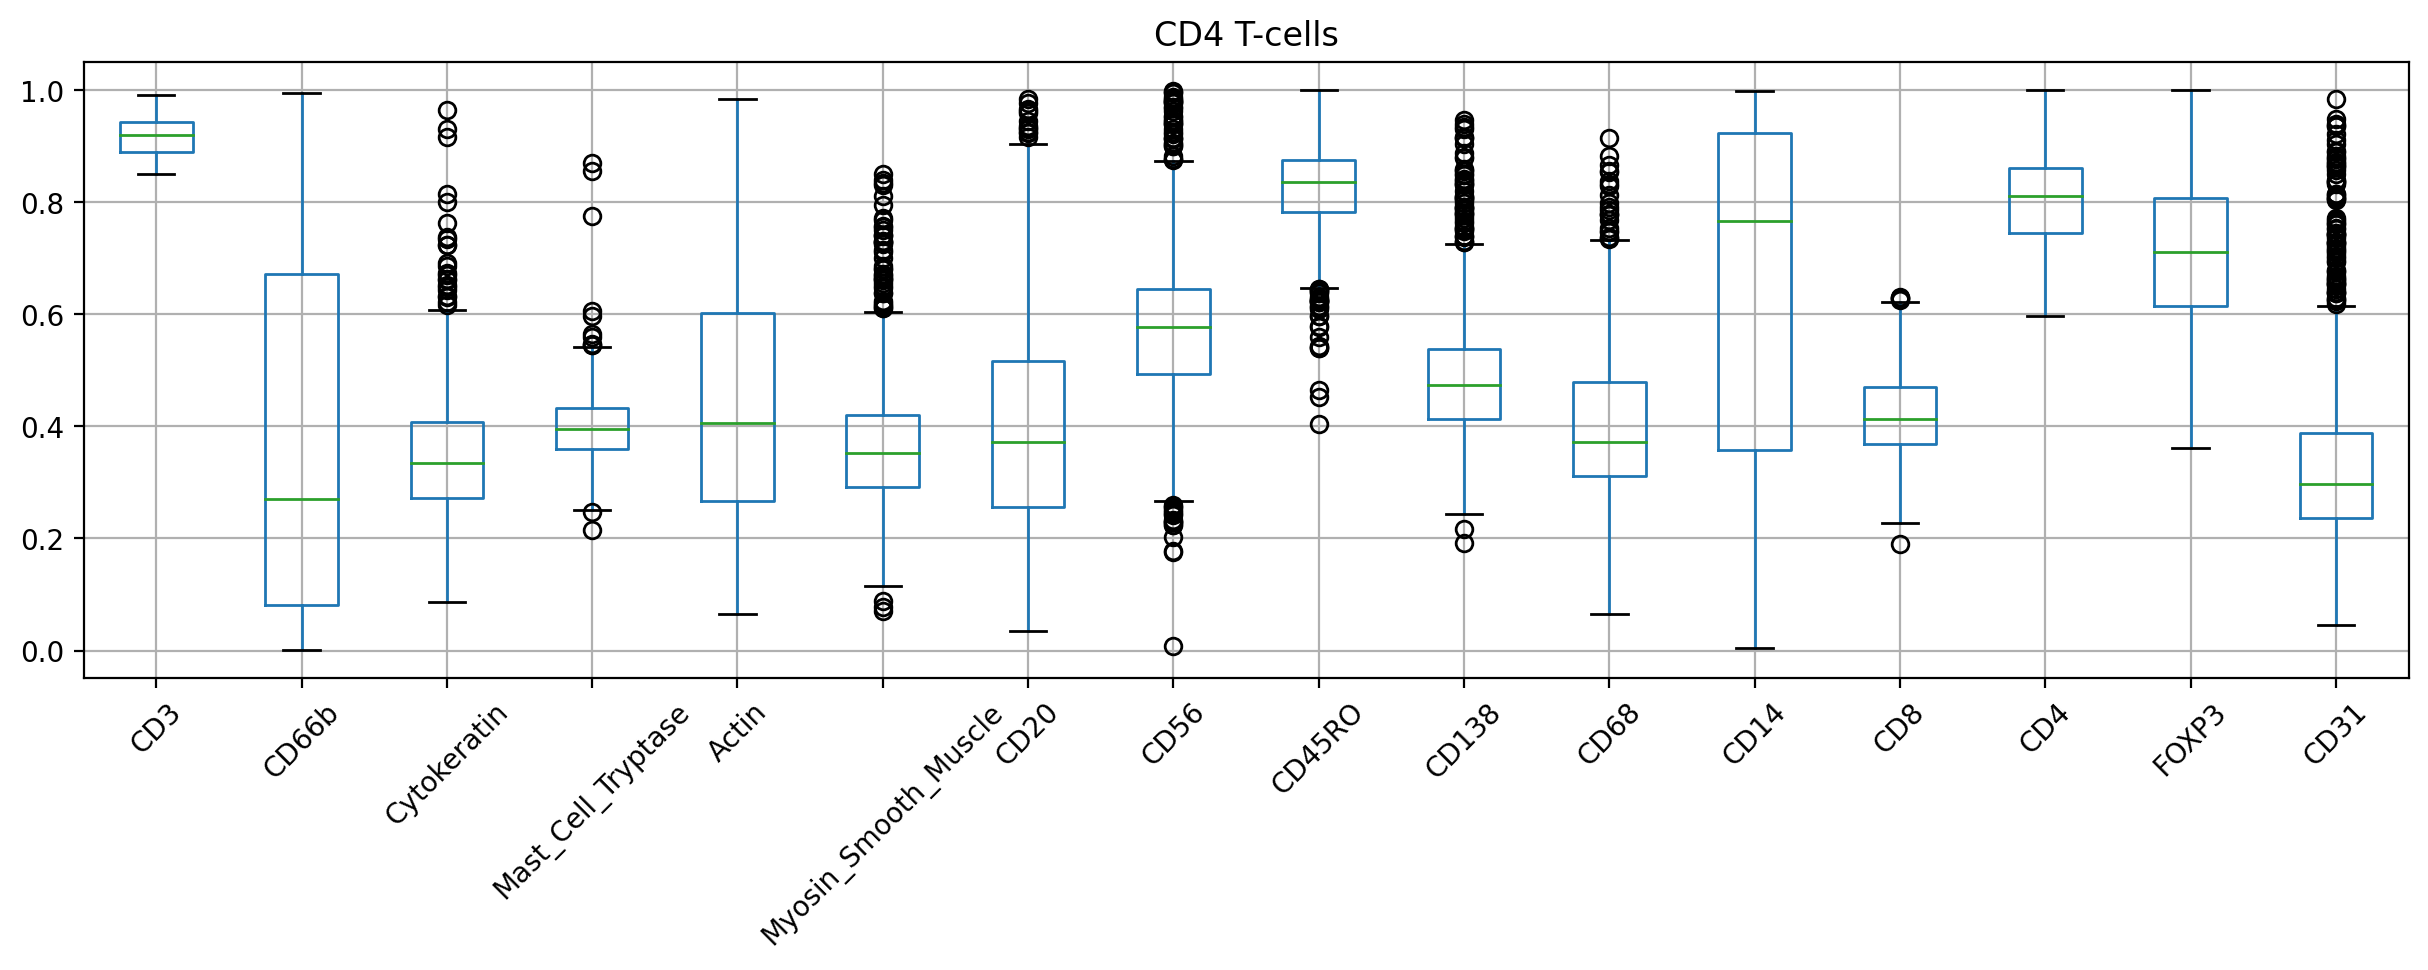

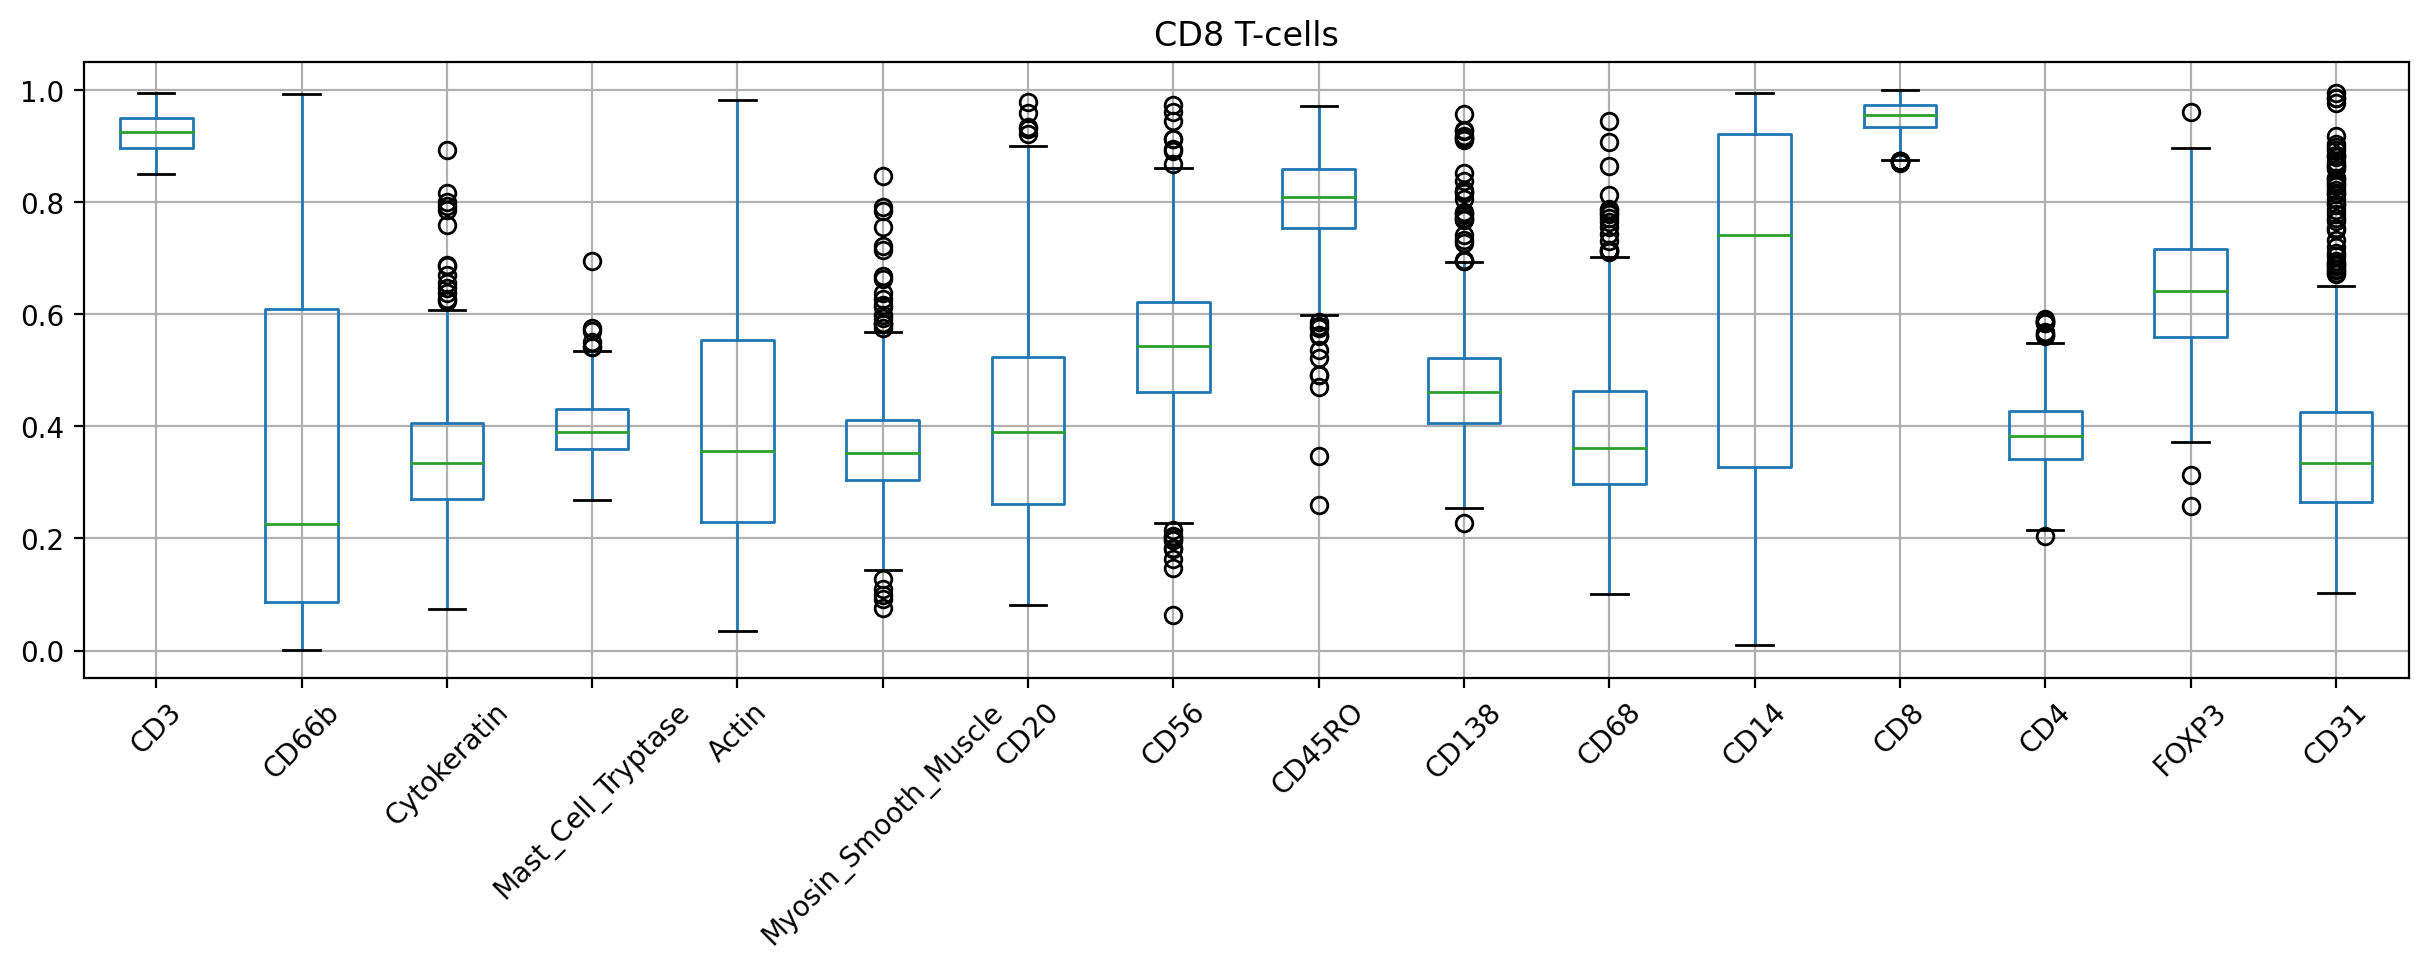

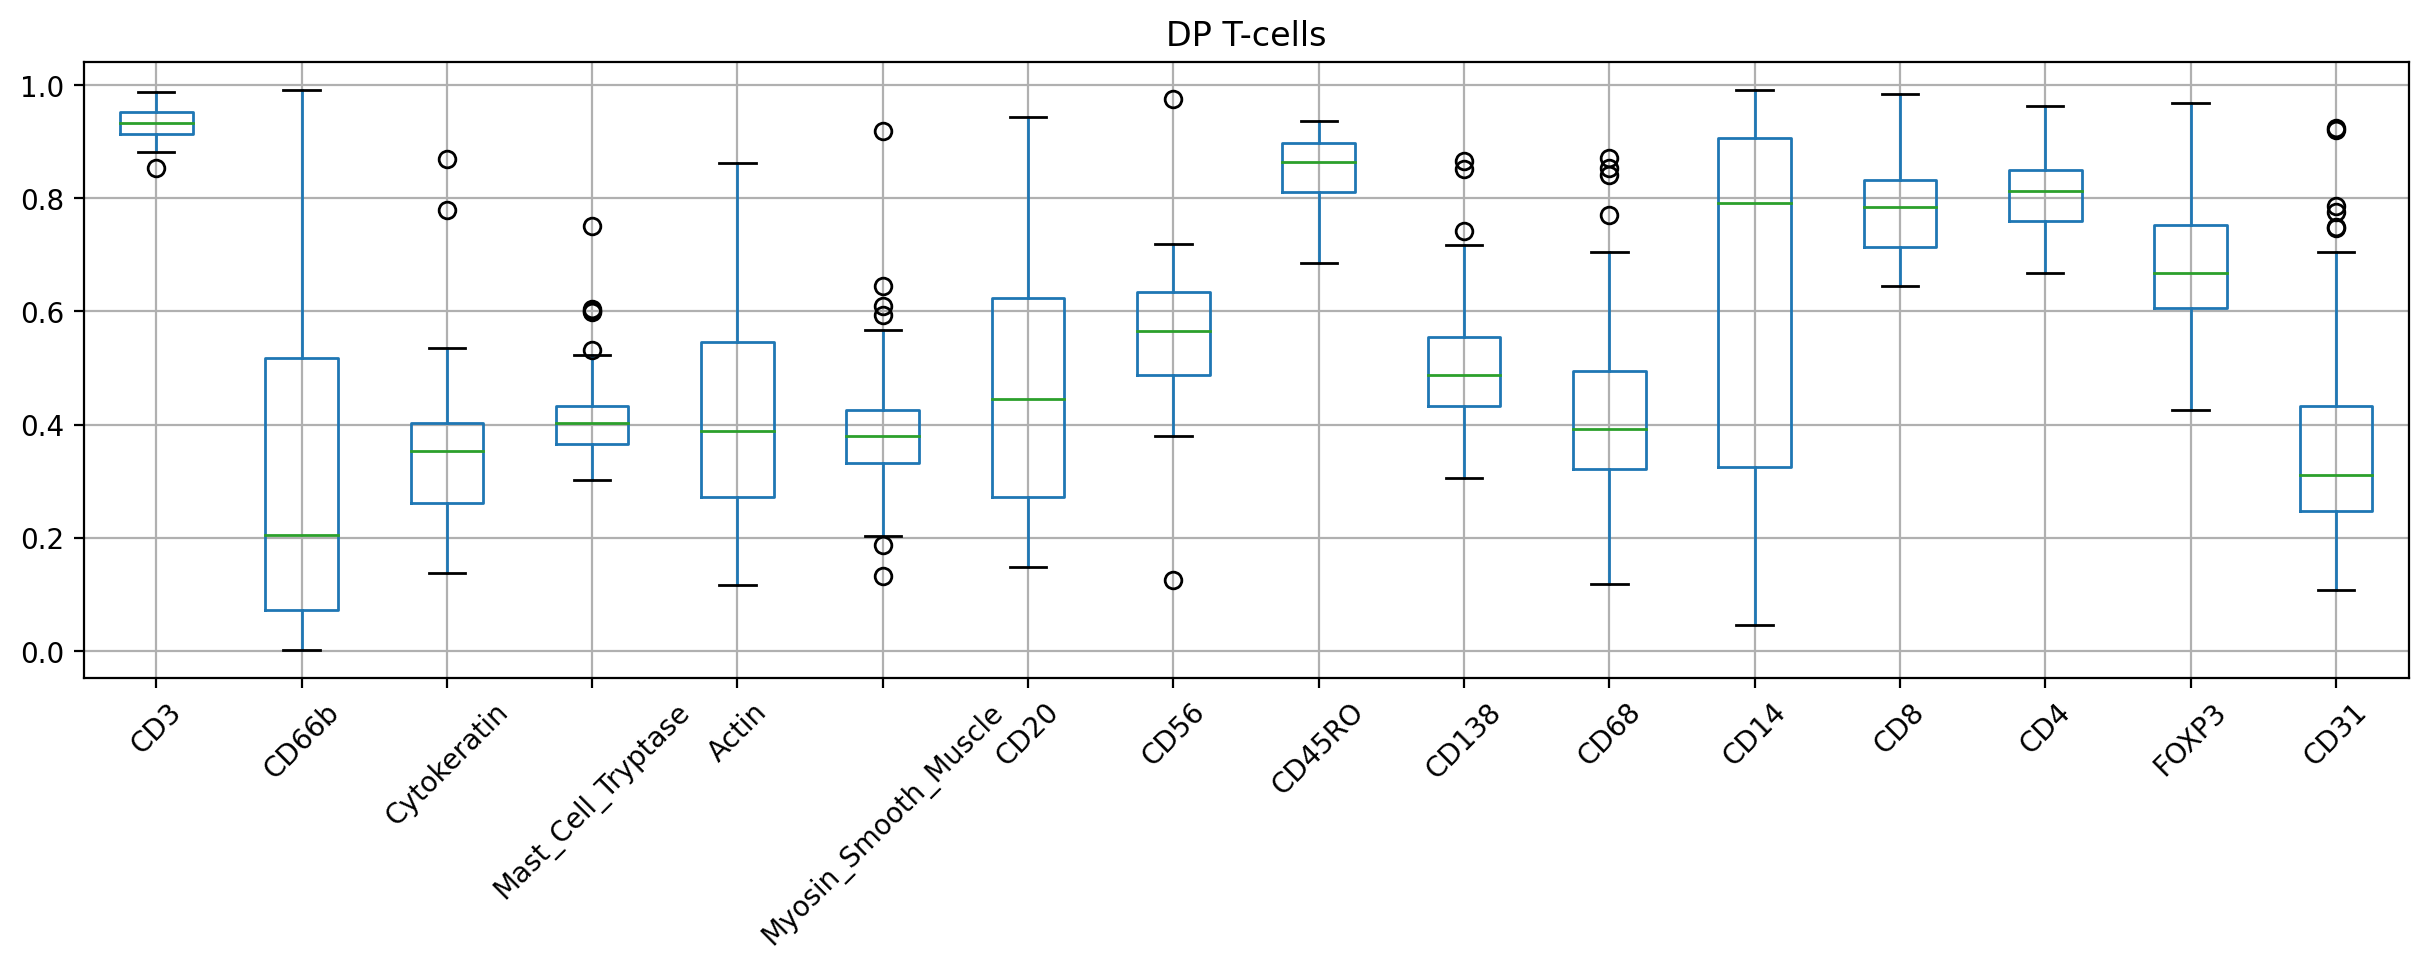

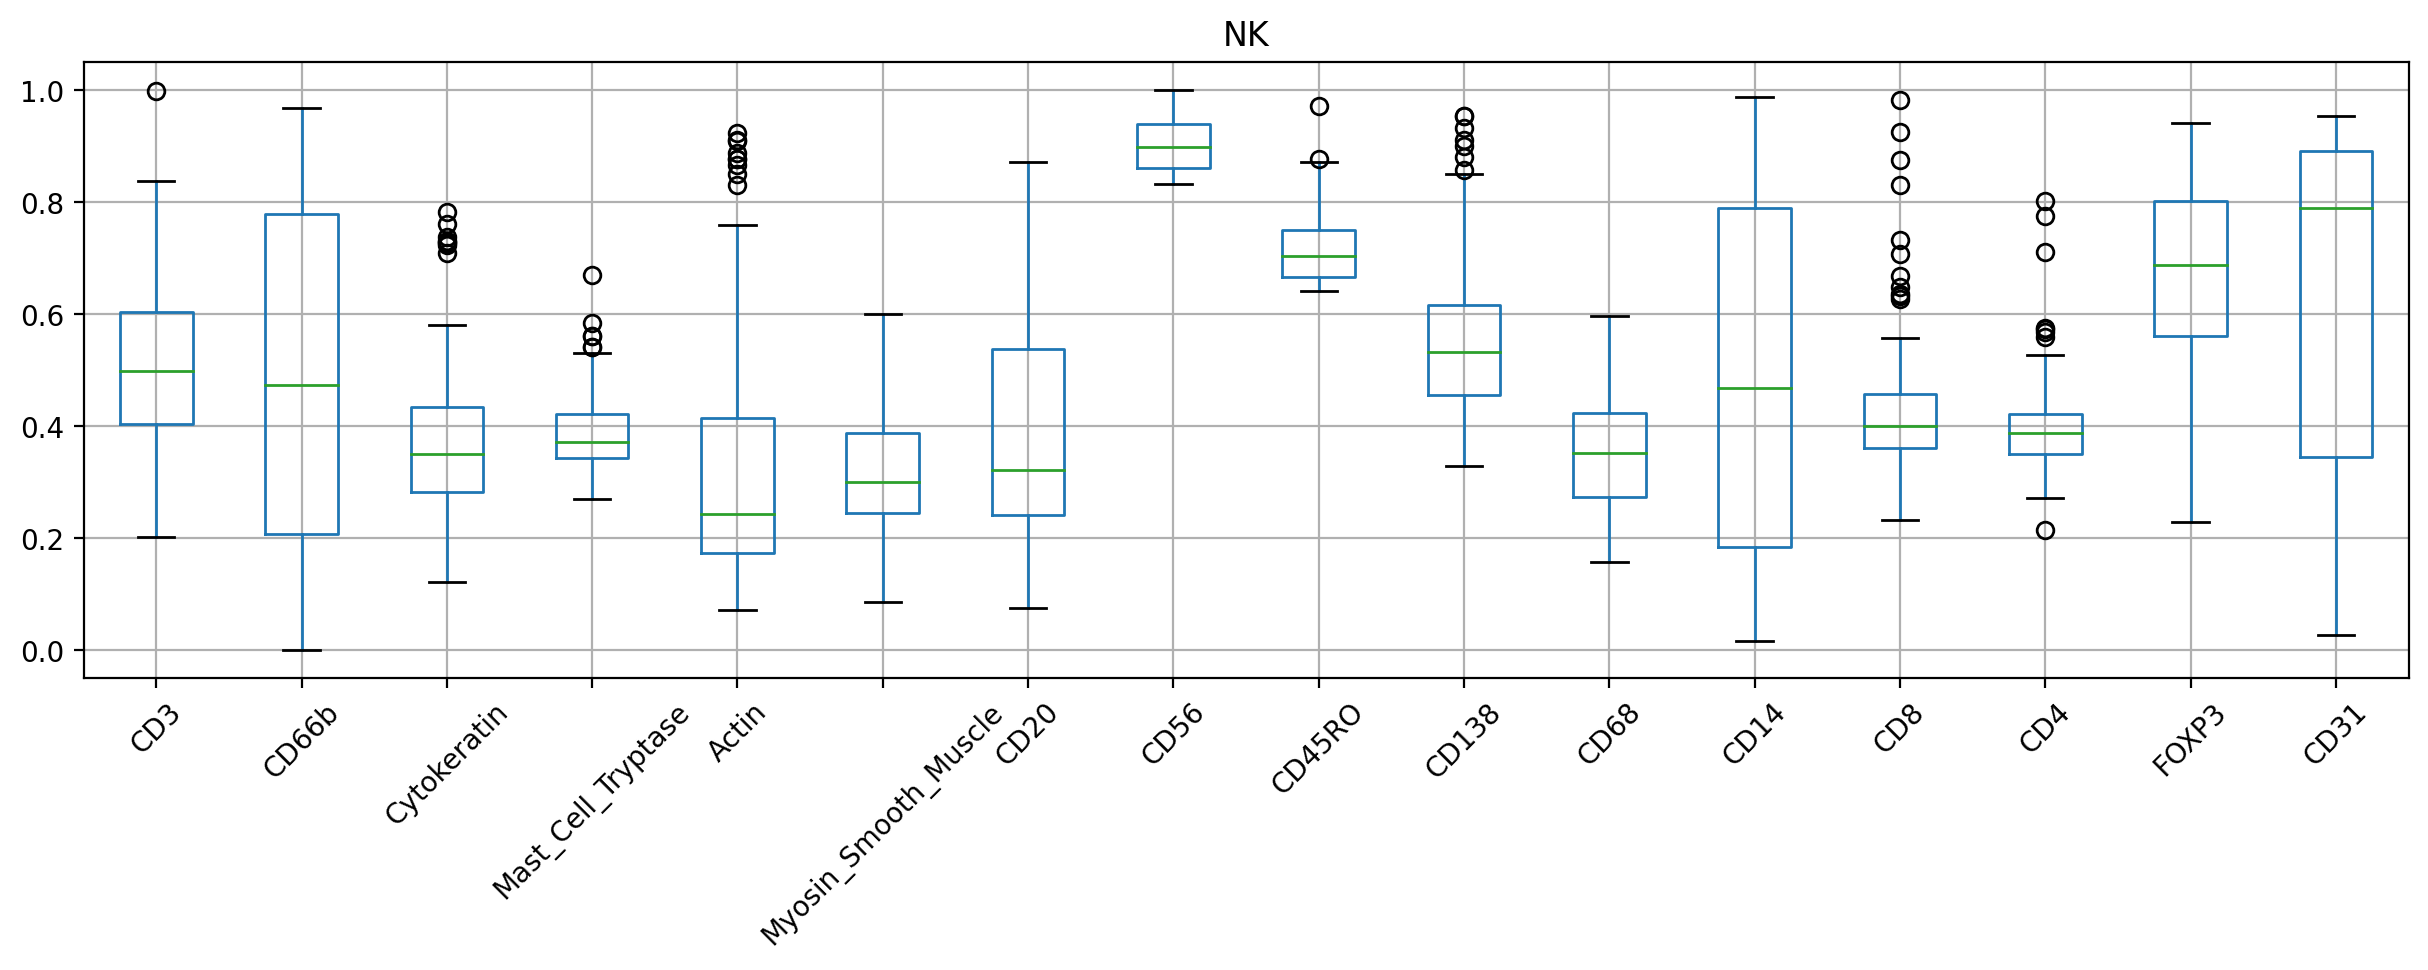

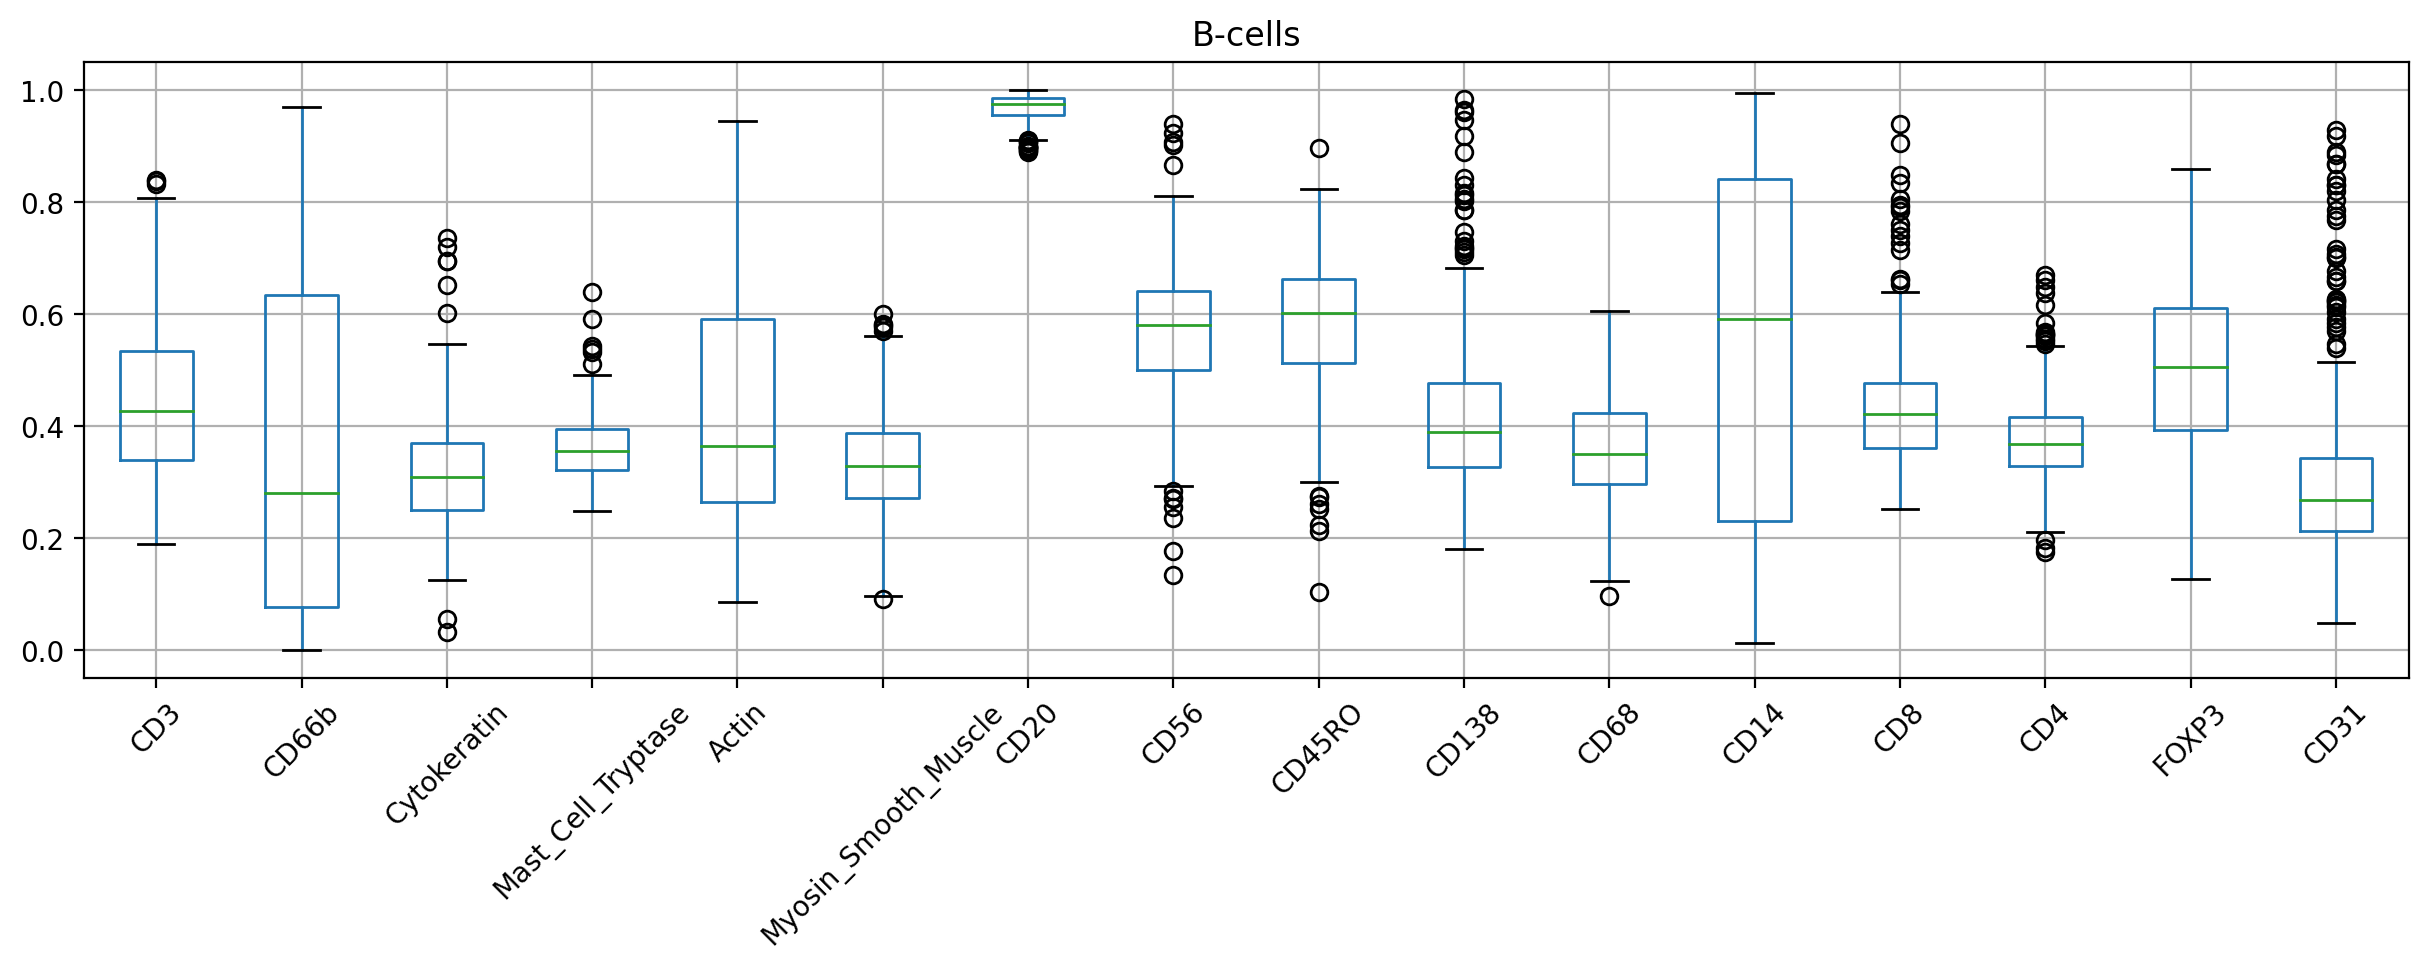

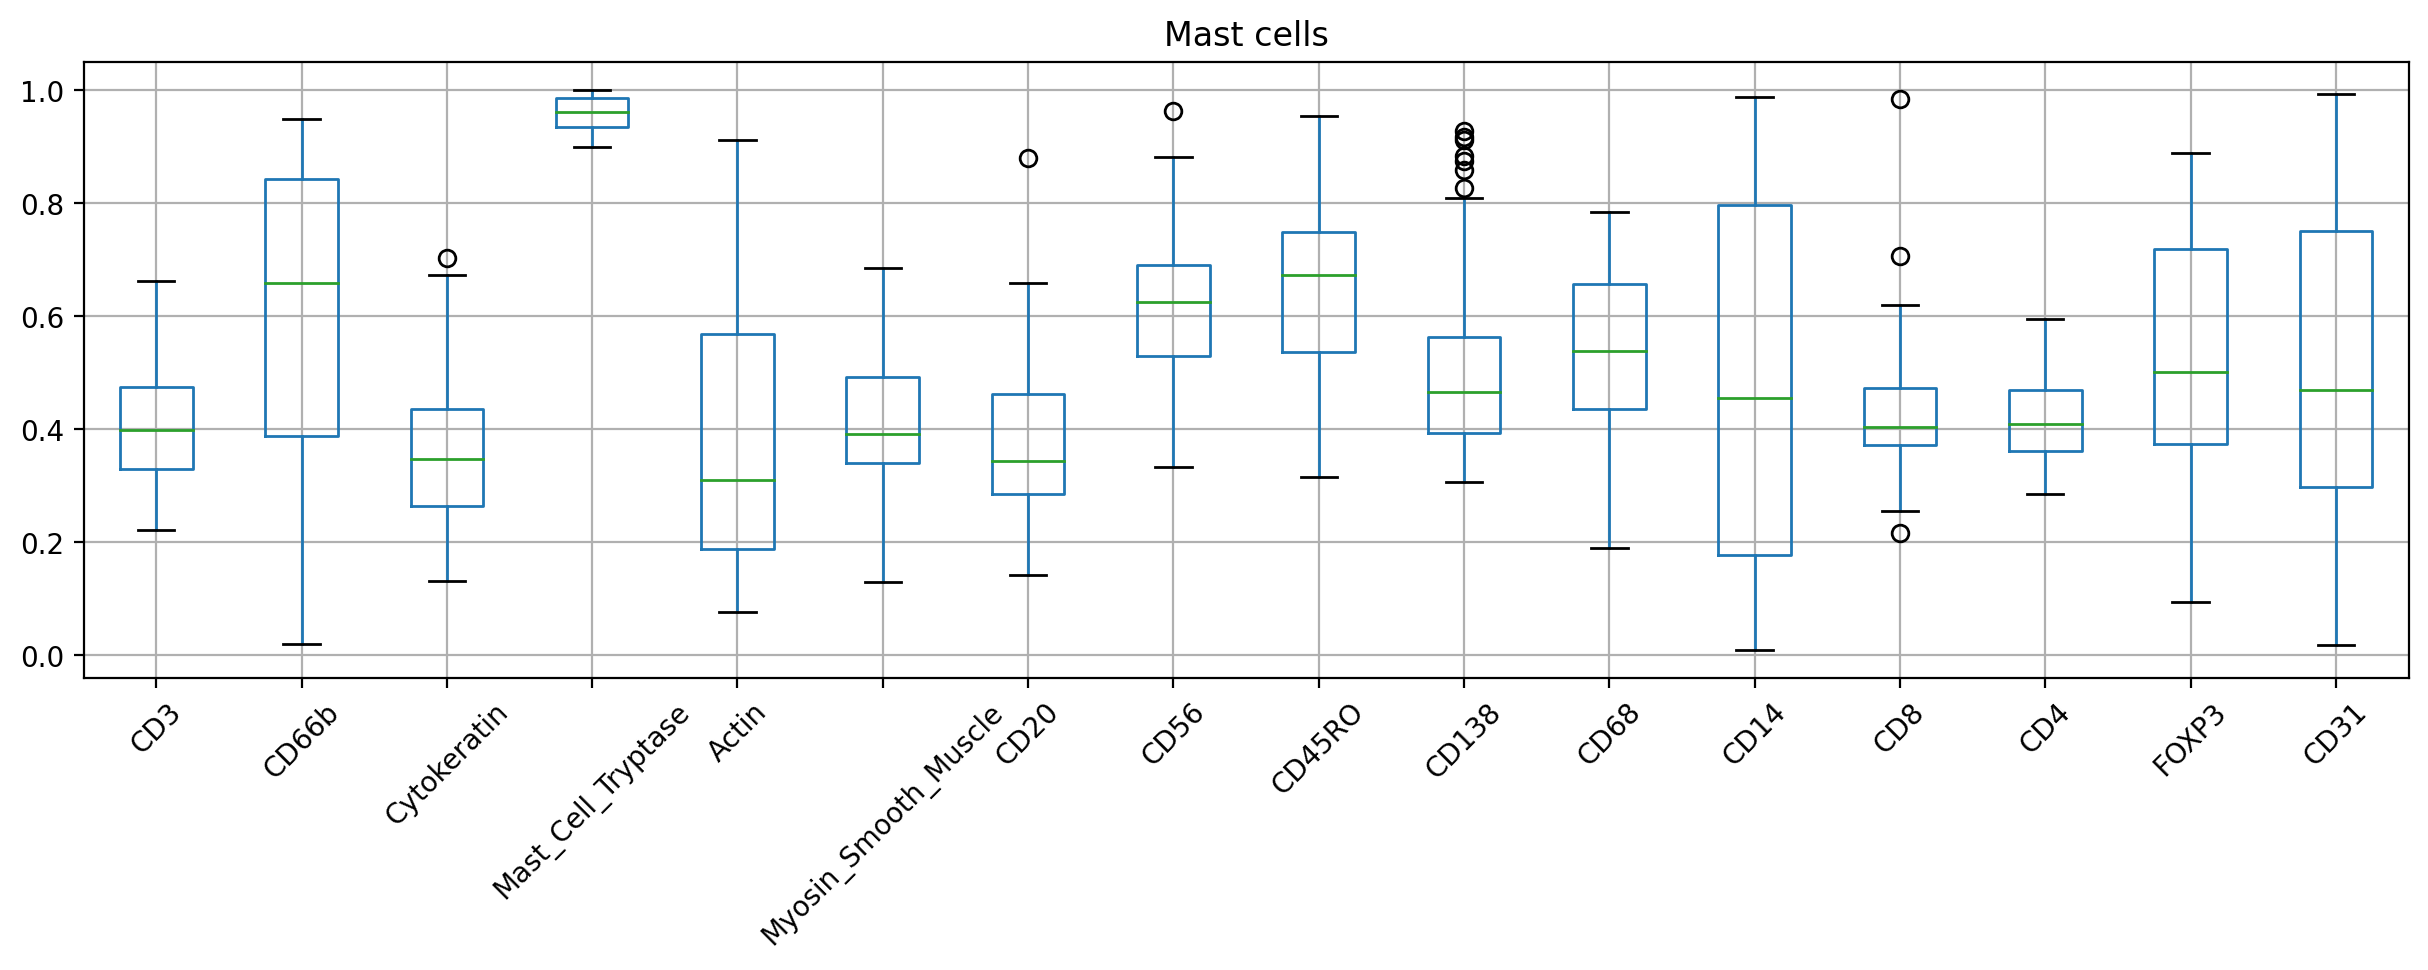

In [19]:
for cell_type,labels in type_label_map.items():
    fig, ax = plt.subplots(1,1, figsize=(15, 4))
    celesta_pmap_filt.loc[celesta_pmap_filt['cell_label'].isin(labels)].boxplot(
        column=markers_list,
        ax=ax,
        rot=45)
    #ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
    plt.title(cell_type)
    plt.savefig(data_dir / 'round_{s}'.format(s=round_suffix)   / 'annotation_plots' / 'boxplot_expressionP_{c}.png'.format(c=cell_type),format='png',bbox_inches="tight")

In [83]:
seg_masks=tifff.imread(seg_masks_path)

In [84]:
for cell_type,labels in type_label_map.items():
    
    canvas=np.zeros(seg_masks.shape,dtype='uint8')
    canvas[np.isin(seg_masks,labels)]=255
    tifff.imwrite( data_dir / 'round_{s}'.format(s=round_suffix) / 'annotation_masks' / '{c}_annotations.tif'.format(c=cell_type), canvas )
    

# Filter celesta results

In [42]:
celesta_dict={'cell_id':img_data.Cell.values,
             'cell_type':celesta_output['Final cell type'].values
             }

In [43]:
df_celesta=pd.DataFrame(celesta_dict)

In [44]:
df_celesta_filt=df_celesta.loc[df_celesta['cell_id'].isin(df_macsiq_filt['cell_id'].values)]

In [45]:
print(df_macsiq_filt.shape)
print(df_celesta_filt.shape)

(15722, 5)
(15722, 2)


In [46]:
num_types={'Unknown':0}
for key,val in lineage_info.items():
    num_types[key]=val[2]

In [47]:
df_celesta_filt.insert(2,'type_no',df_celesta_filt['cell_type'].values)

In [48]:
for cell_type,val in num_types.items():
    df_celesta_filt.loc[df_celesta_filt.cell_type==cell_type,'type_no']=val

In [49]:
df_celesta_filt.to_csv(data_dir / 'round_{s}'.format(s=round_suffix) /'celesta_level{r}.csv'.format(r=round_suffix),index=False)

# 2. Estimate thresholds for celesta

In [20]:
celesta_pmap=pd.read_csv(data_dir / 'celesta_pmap.csv')
celesta_pmap.rename(columns={'Unnamed: 0':'cell_label'},inplace=True)

## 2.1 Otsu

In [24]:
thr_otsu={}
for marker in celesta_pmap.columns[1::]:
    
    #thr_otsu[marker]=[f'{threshold_multiotsu(celesta_pmap[marker].values,classes=3)[0]:.2f}']
    thr_otsu[marker]=threshold_multiotsu(celesta_pmap[marker].values,classes=3)
    
thr_otsu_df=pd.DataFrame(thr_otsu)
#thr_otsu_df.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)   / 'celesta_output' / 'otsu' / 'thr_input.csv',index=False)

#thr_otsu_df
thr_otsu

{'CD3': array([0.40039062, 0.67773438]),
 'CD66b': array([0.30273438, 0.68554688]),
 'Cytokeratin': array([0.35742188, 0.66210938]),
 'Mast_Cell_Tryptase': array([0.36914062, 0.59179688]),
 'Actin': array([0.34570312, 0.64648438]),
 'Myosin_Smooth_Muscle': array([0.33789062, 0.56835938]),
 'CD20': array([0.34179688, 0.55664062]),
 'CD56': array([0.45117188, 0.63085938]),
 'CD45RO': array([0.49023438, 0.67382812]),
 'CD138': array([0.41992188, 0.65039062]),
 'CD68': array([0.36132812, 0.57226562]),
 'CD14': array([0.30273438, 0.68554688]),
 'CD8': array([0.42382812, 0.67773438]),
 'CD4': array([0.43554688, 0.61914062]),
 'FOXP3': array([0.39648438, 0.63085938]),
 'CD31': array([0.32226562, 0.64257812])}

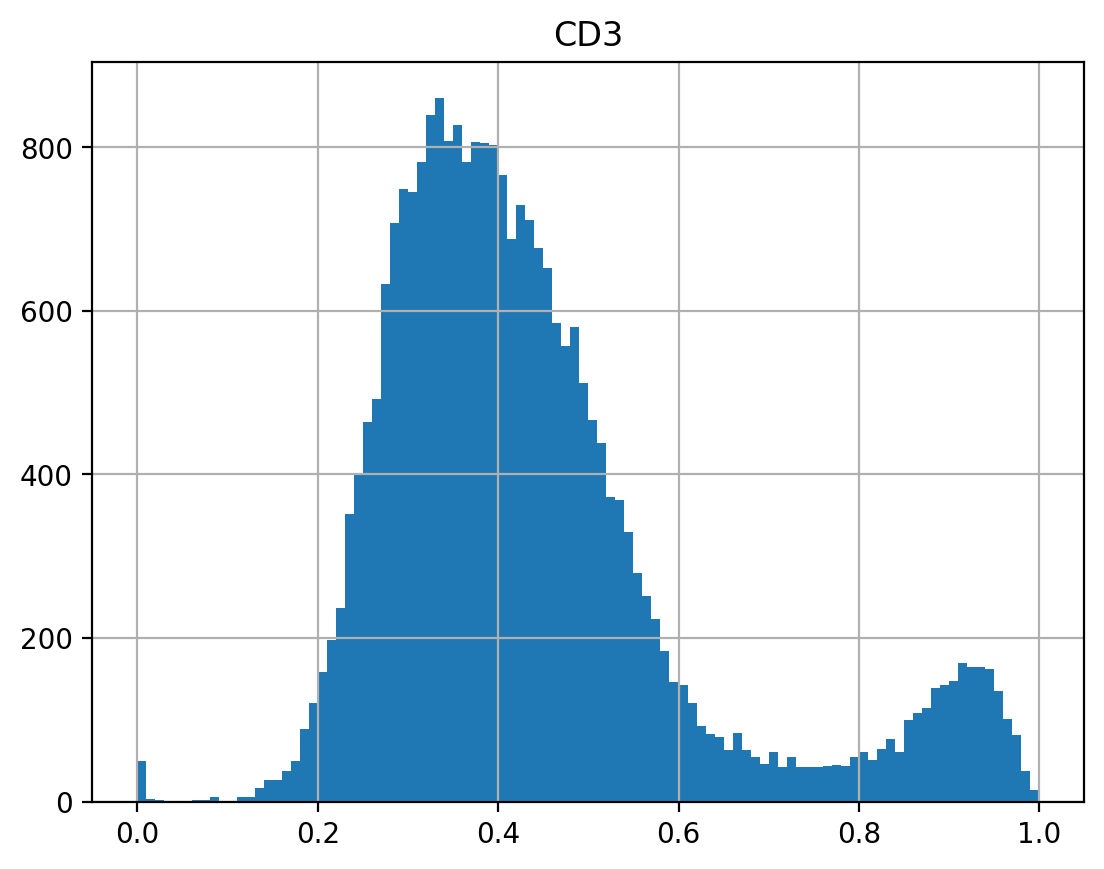

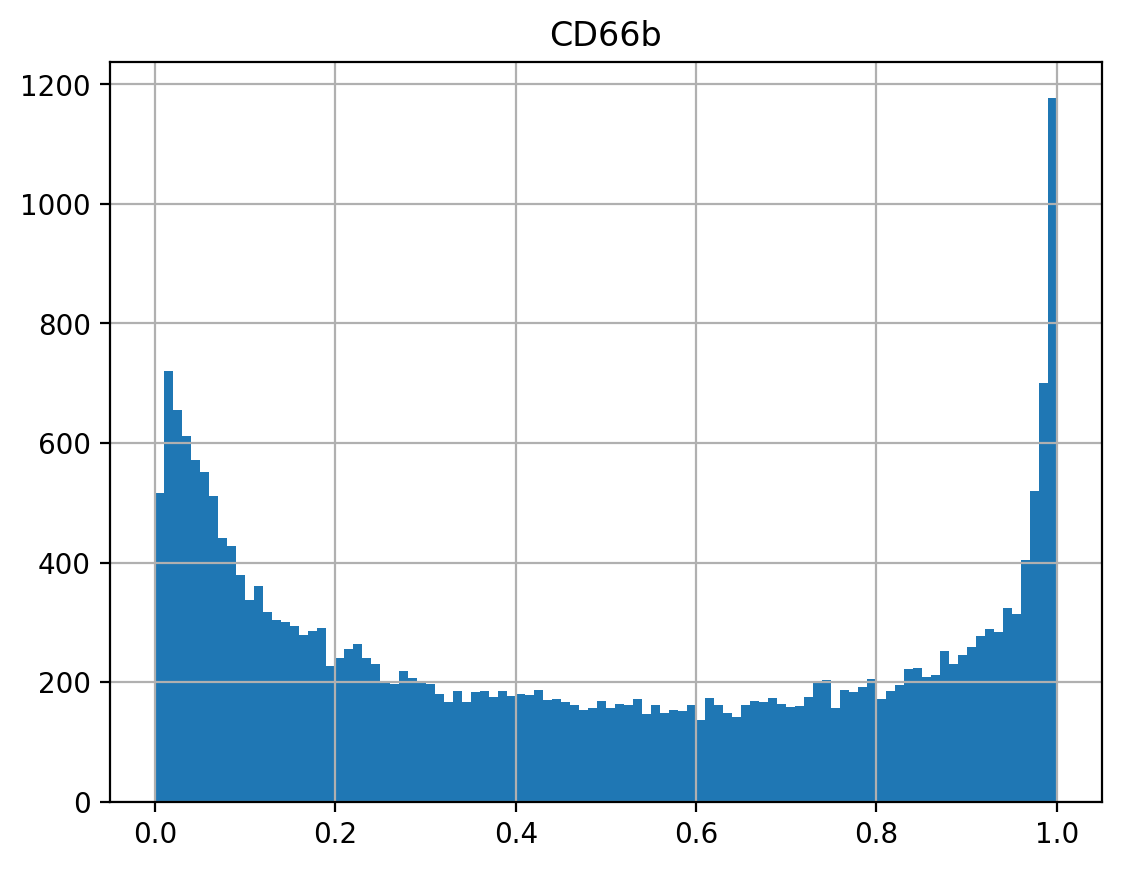

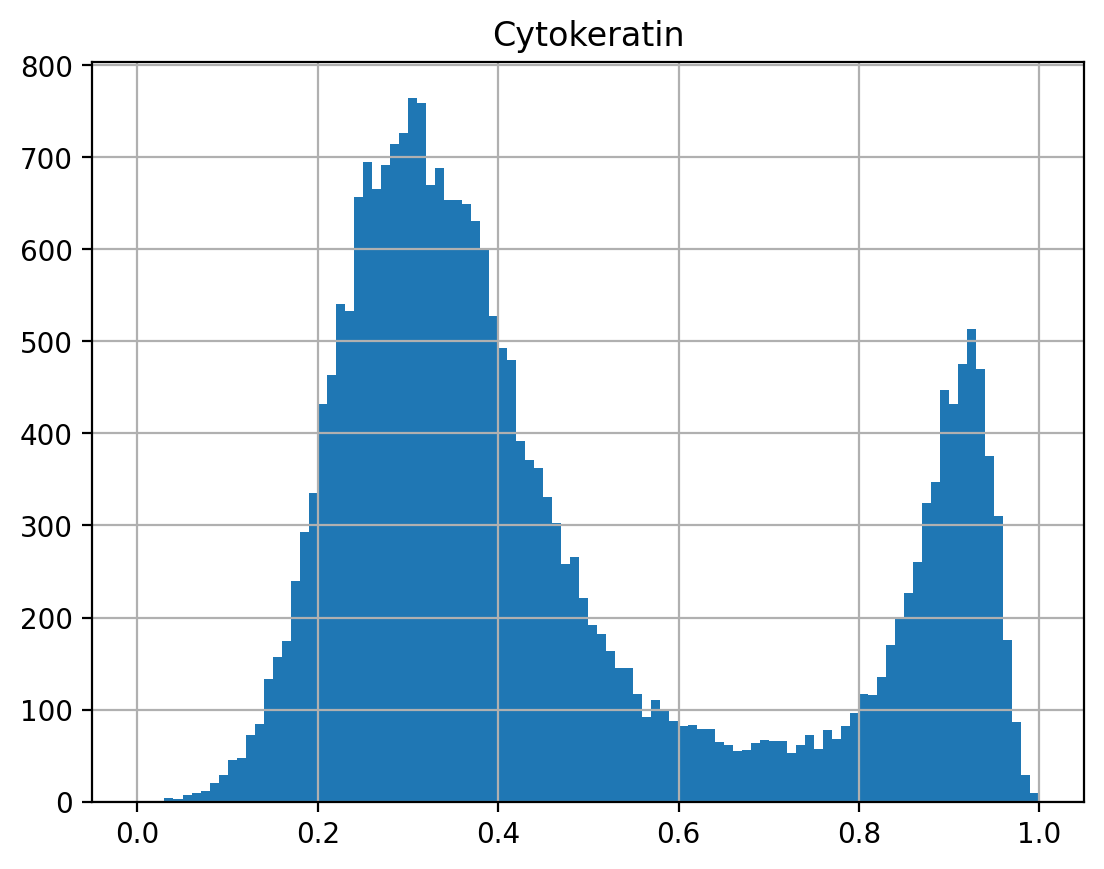

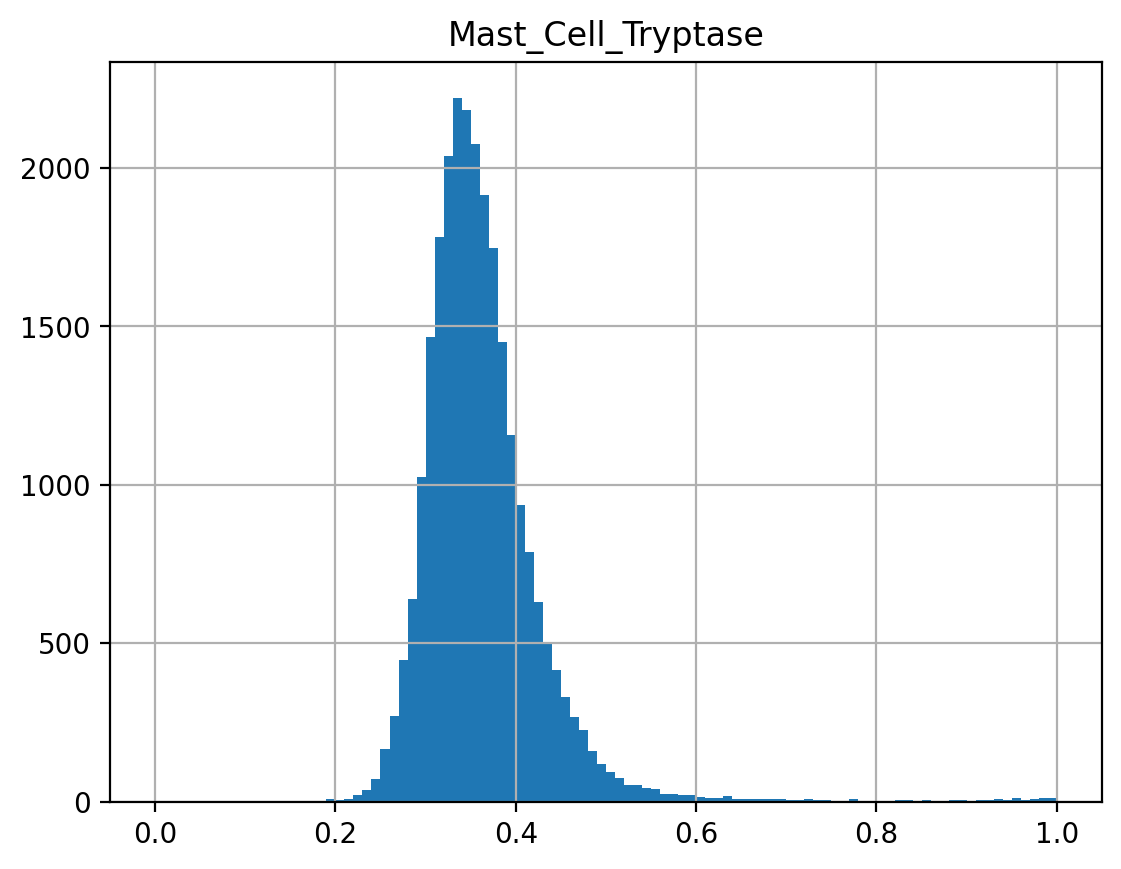

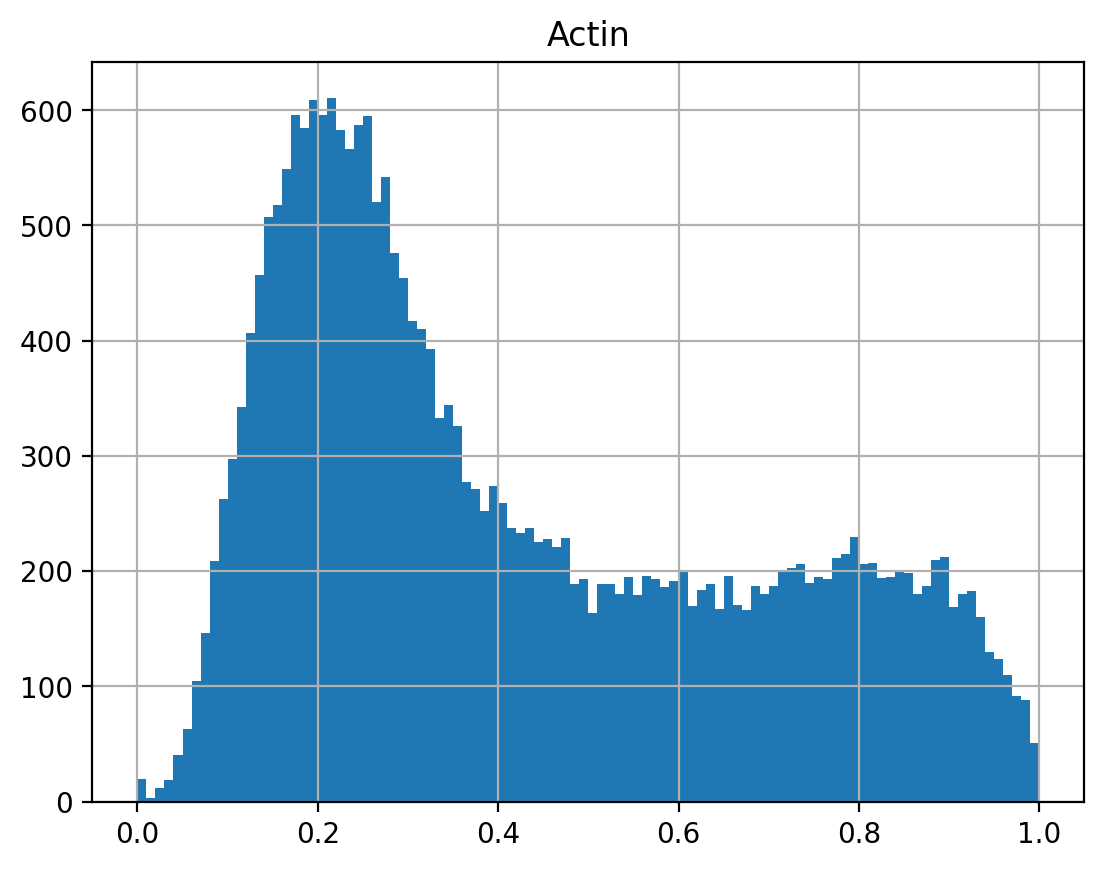

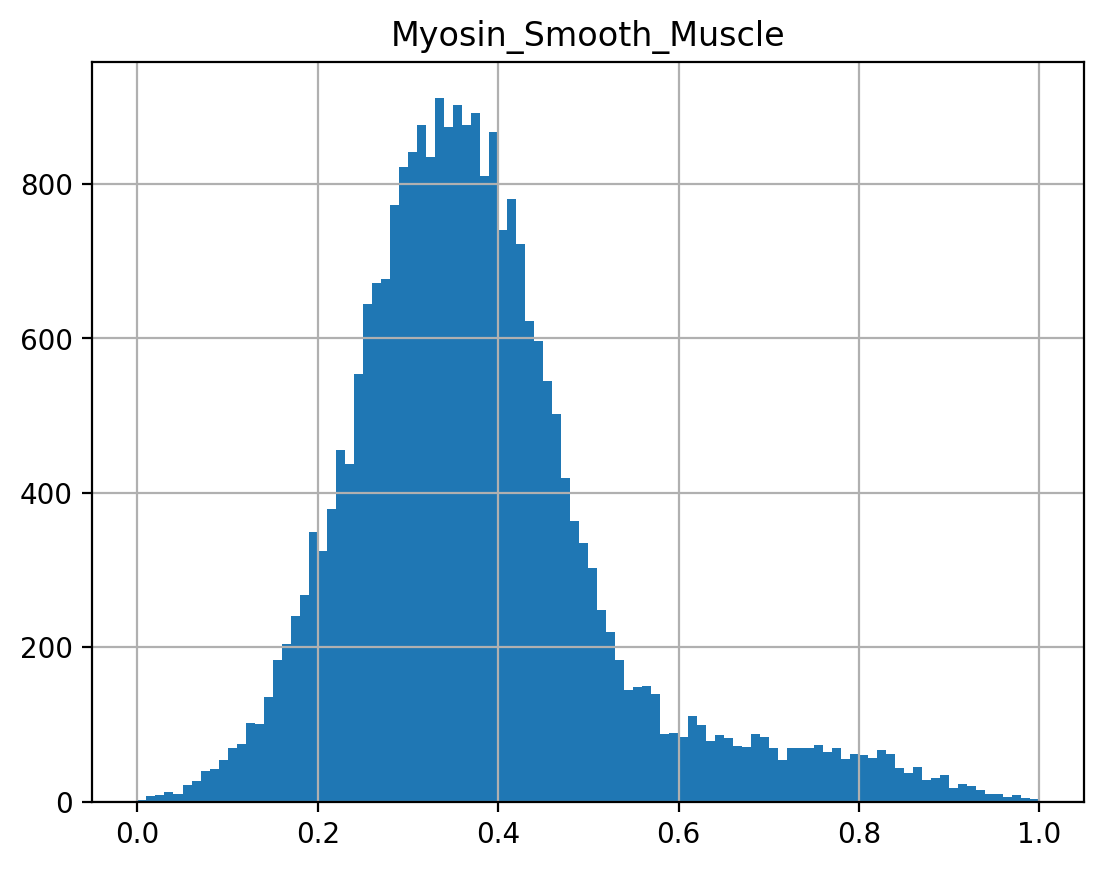

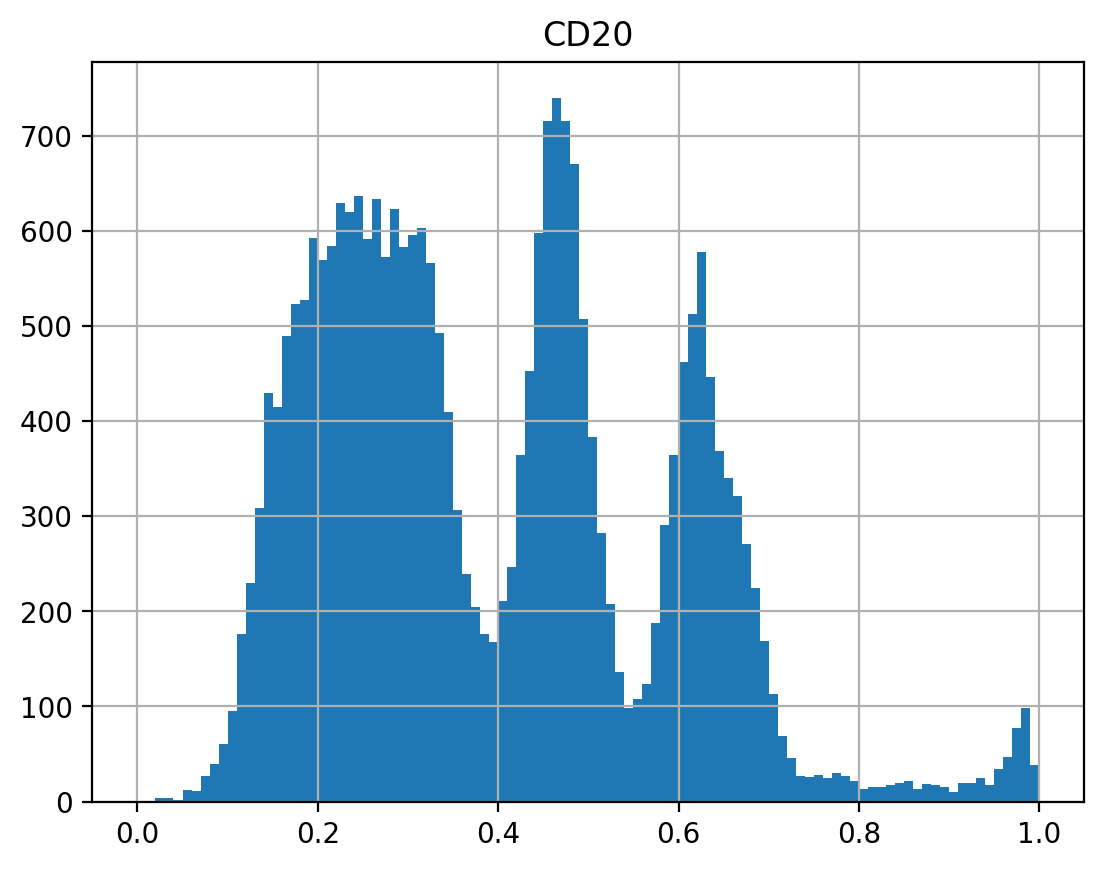

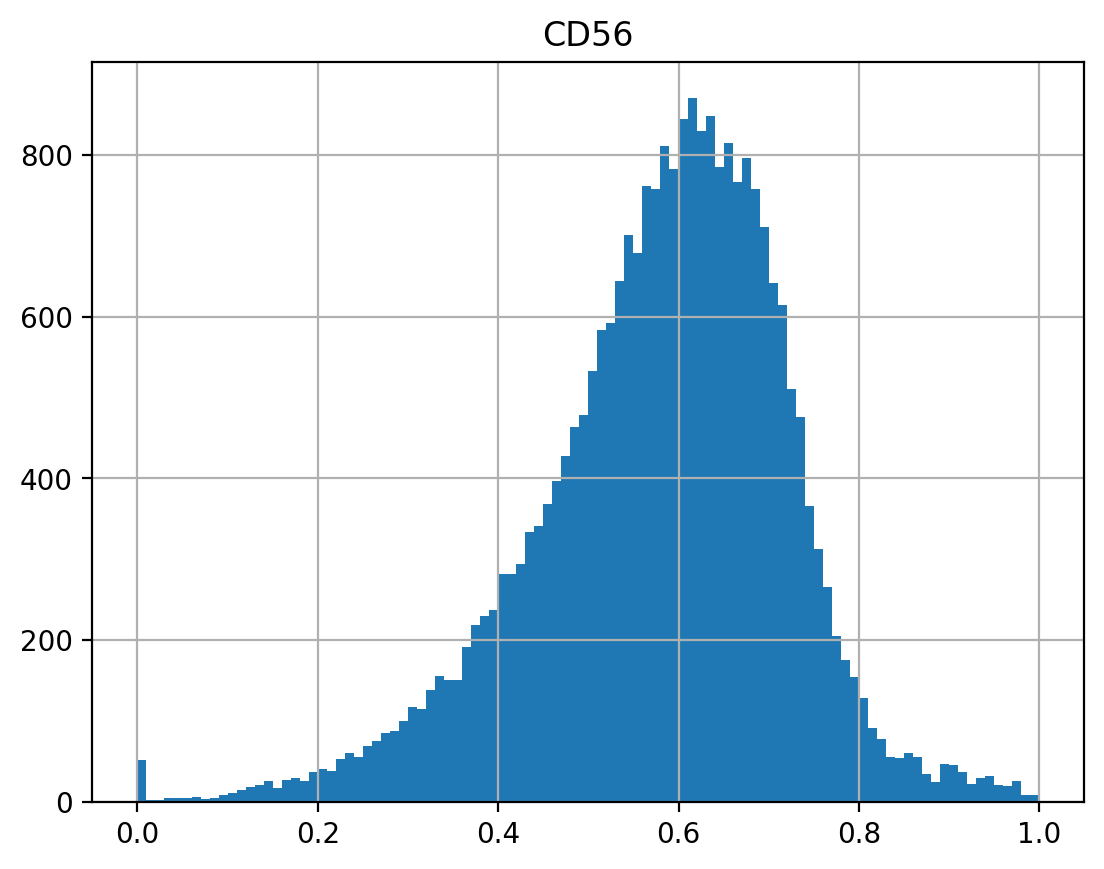

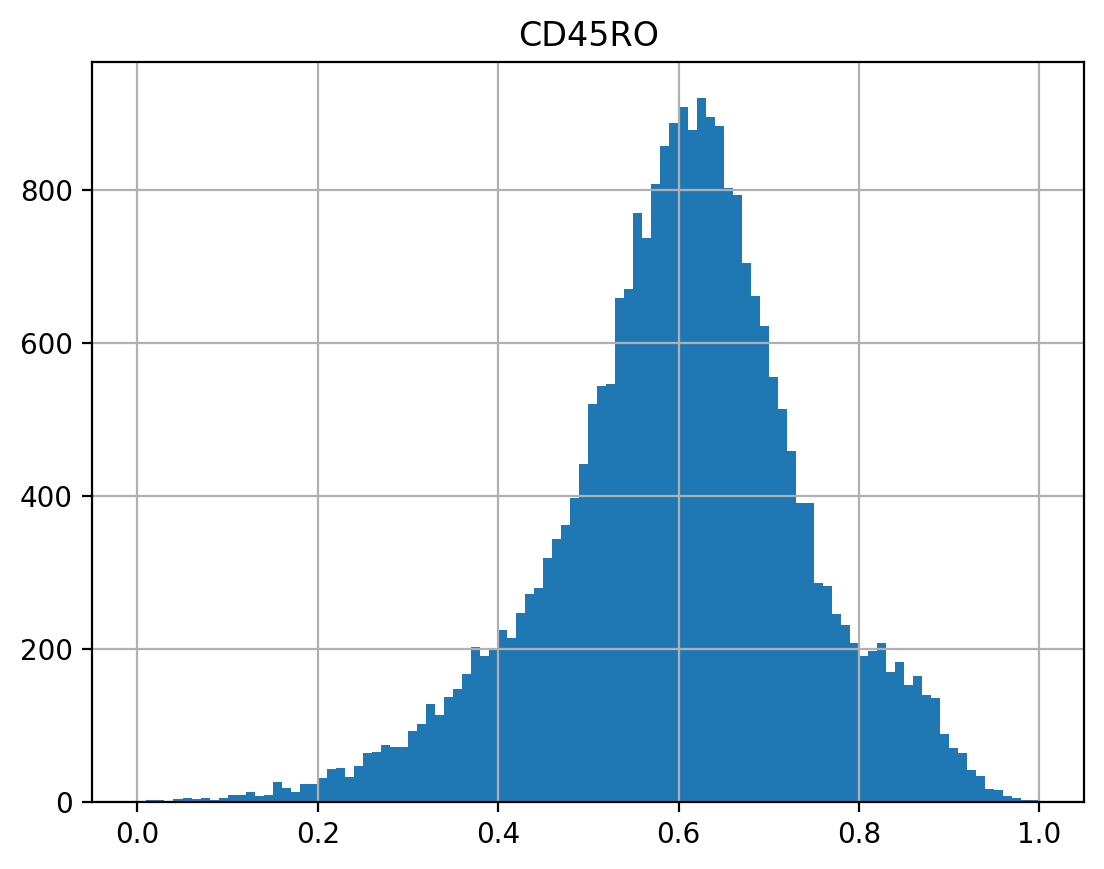

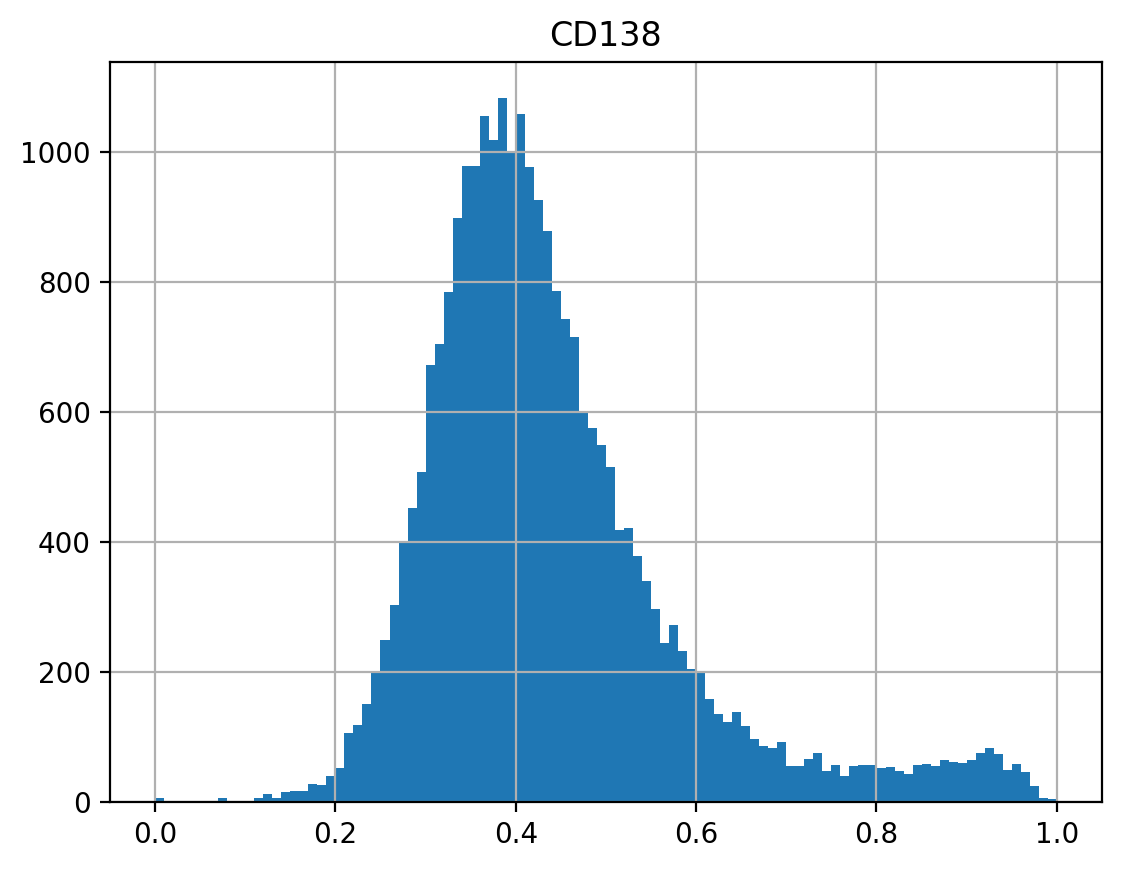

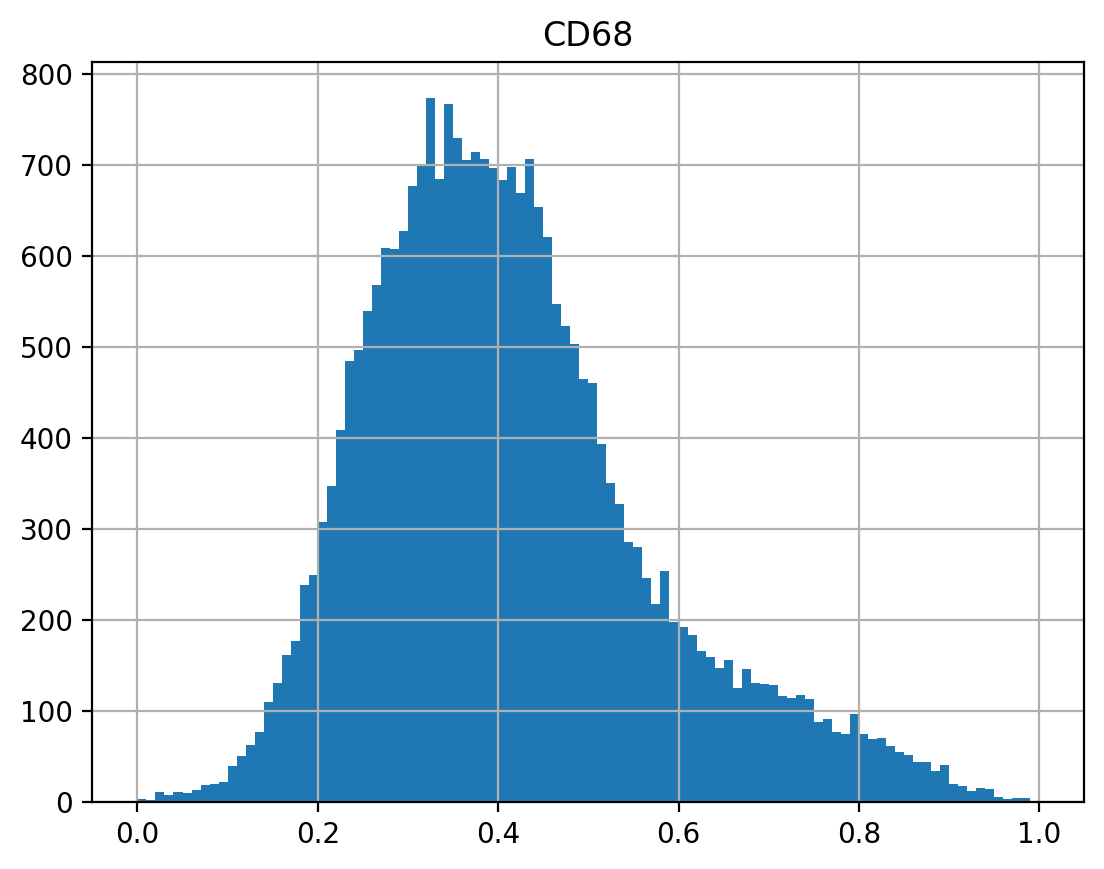

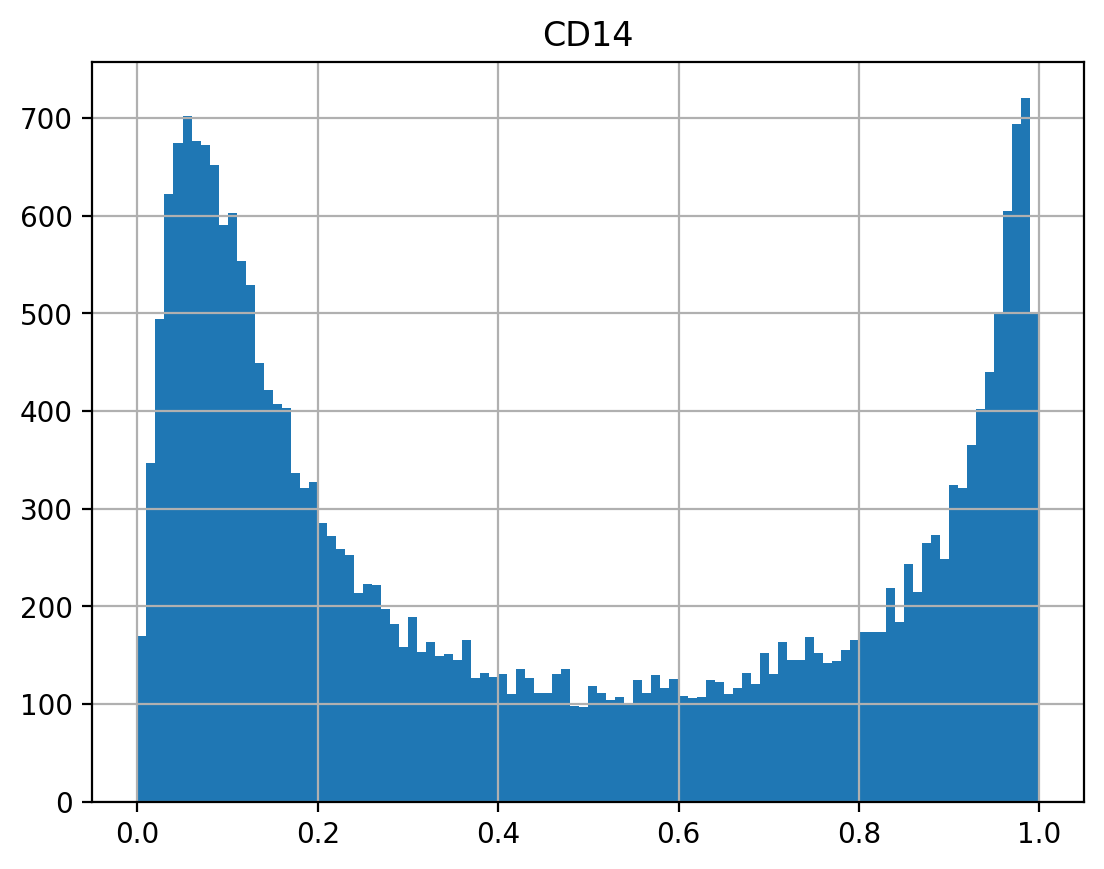

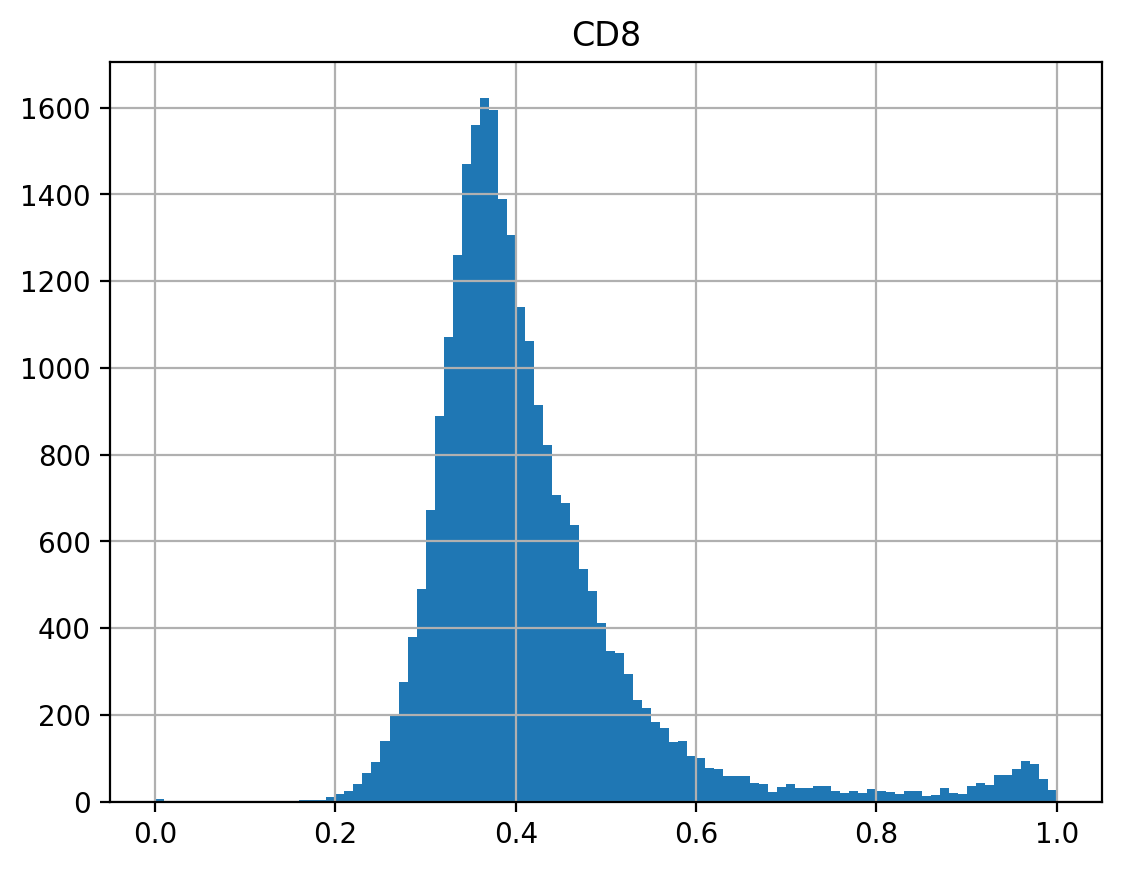

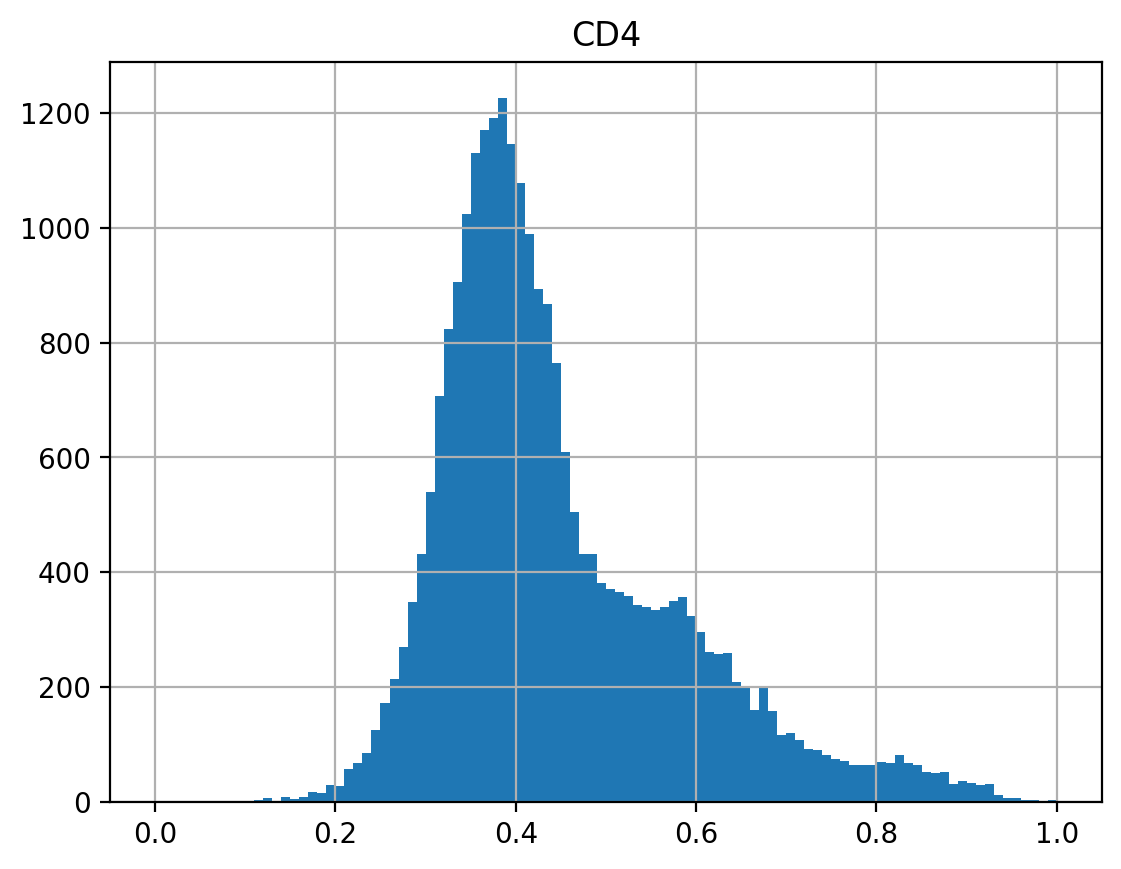

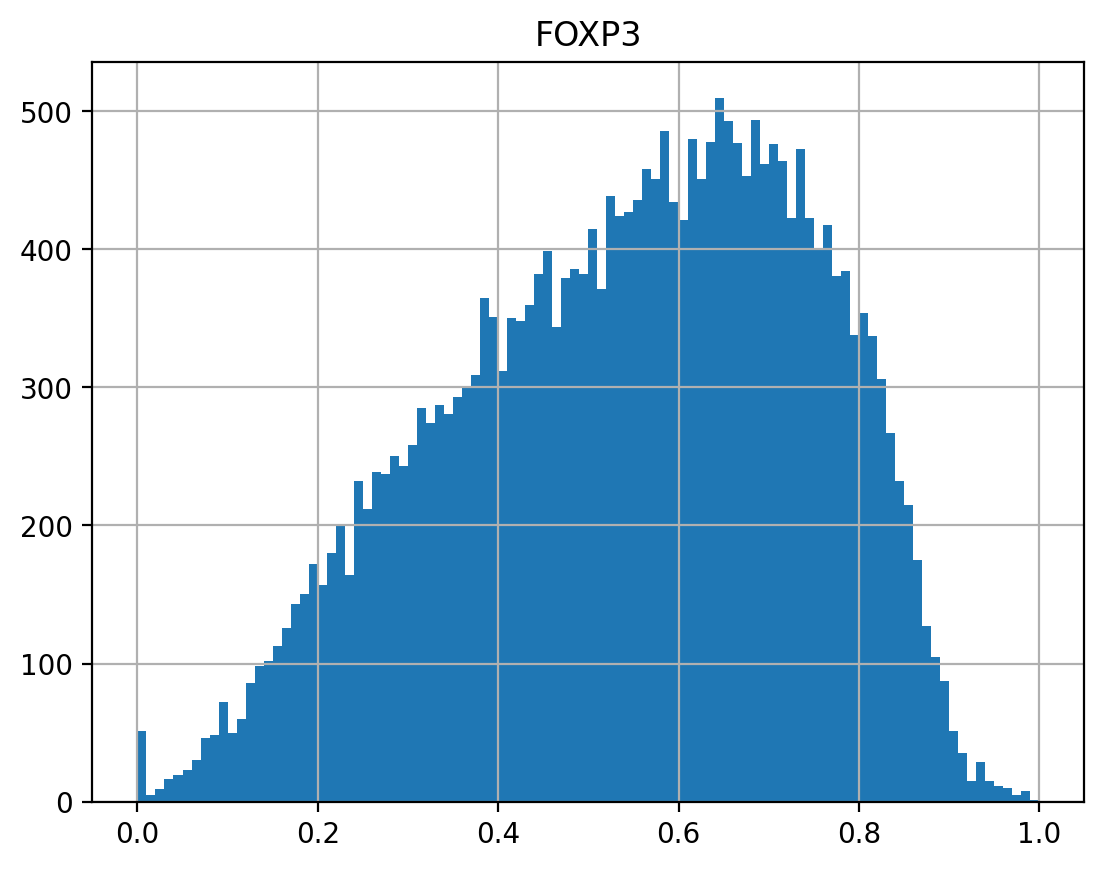

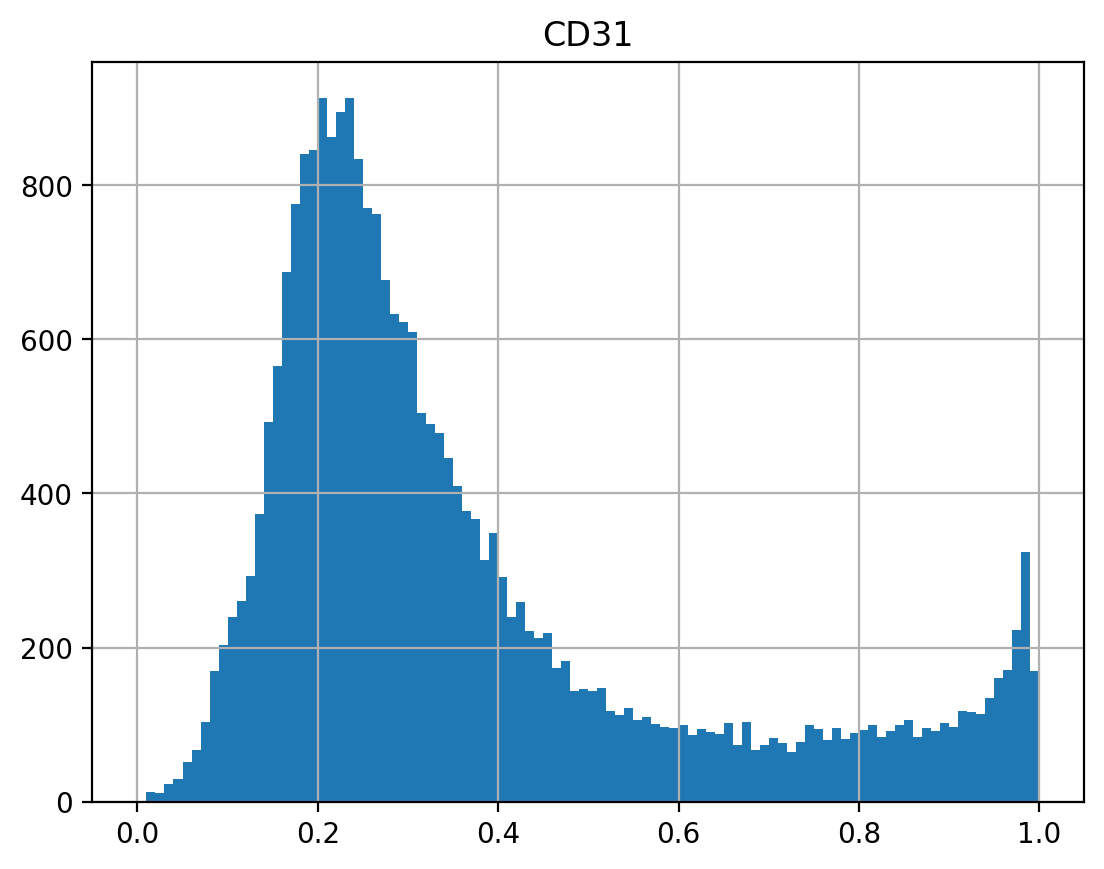

In [35]:
for marker in celesta_pmap.columns[1::]:
    celesta_pmap.hist(column=marker,bins=100)

## 2.2 Kmeans 

In [36]:
def cluster(img, K=3):
    
    aux=np.float32(img.flatten())
    criteria=(cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,10,1.0)
    ret,label,center=cv.kmeans(aux,K,None,criteria,3, cv.KMEANS_PP_CENTERS )#cv.KMEANS_RANDOM_CENTERS)
    og_center=np.copy(center)
    low=np.argmin(center)
    hi=np.argmax(center)
    mid=np.setdiff1d([0,1,2],[low,hi])[0]
    center[low]=1
    center[mid]=2
    center[hi]=3
    clustered=(center[label.flatten()]).reshape(img.shape)
    
    return clustered,og_center

In [37]:
expression_map={}
for marker in celesta_pmap.columns[1::]:
    cluster_labels,cent=cluster(celesta_pmap[marker].values)
    expression_map[marker+'_exp_level']=cluster_labels
df_expression=pd.DataFrame(expression_map,index=celesta_pmap.index.values)

expression_map_cluster=pd.concat([celesta_pmap,df_expression],axis=1)
expression_map_cluster.to_csv(data_dir / 'celesta_pmap_exp_level_clusters.csv',index=False)
expression_map_cluster

,cell_label,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,...,CD20_exp_level,CD56_exp_level,CD45RO_exp_level,CD138_exp_level,CD68_exp_level,CD14_exp_level,CD8_exp_level,CD4_exp_level,FOXP3_exp_level,CD31_exp_level
0,1,0.365390,0.030263,0.227827,0.338736,0.778946,0.270397,0.196068,0.393930,0.653326,...,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0
1,2,0.155278,0.352776,0.495362,0.350731,0.848248,0.300029,0.180489,0.312740,0.517845,...,1.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0
2,3,0.694887,0.125403,0.301102,0.365518,0.532395,0.345496,0.293001,0.169489,0.675915,...,1.0,1.0,3.0,1.0,2.0,3.0,2.0,3.0,2.0,1.0
3,4,0.083916,0.386513,0.108594,0.334409,0.564205,0.769635,0.505292,0.189973,0.584317,...,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,5,0.119430,0.426636,0.547941,0.450508,0.333117,0.407027,0.342674,0.282912,0.562413,...,2.0,1.0,2.0,1.0,3.0,1.0,3.0,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25800,25801,0.411455,0.613424,0.396641,0.292556,0.000000,0.431159,0.838558,0.484147,0.597942,...,3.0,2.0,2.0,1.0,3.0,3.0,2.0,1.0,2.0,3.0
25801,25802,0.313515,0.828356,0.499769,0.276807,0.000000,0.480021,0.853470,0.559759,0.327599,...,3.0,2.0,1.0,1.0,3.0,3.0,2.0,2.0,2.0,3.0
25802,25803,0.411371,0.658798,0.434870,0.229602,0.000000,0.447377,0.853860,0.222027,0.340634,...,3.0,1.0,1.0,1.0,3.0,3.0,2.0,2.0,2.0,3.0
25803,25804,0.529551,0.564943,0.931018,0.183066,0.000000,0.424941,0.831923,0.792515,0.377531,...,3.0,3.0,1.0,2.0,3.0,3.0,1.0,3.0,3.0,3.0


In [38]:
thr_kmeans={}

for marker in celesta_pmap.columns[1::]:
    
    threshold_hi=expression_map_cluster.loc[expression_map_cluster[marker+'_exp_level']==3][marker].values.min()
    threshold_mi=expression_map_cluster.loc[expression_map_cluster[marker+'_exp_level']==2][marker].values.max()
    threshold_lo=expression_map_cluster.loc[expression_map_cluster[marker+'_exp_level']==1][marker].values.max()
    
    thr_kmeans[marker]=[f'{threshold_hi:.2f}',f'{threshold_mi:.2f}',f'{threshold_lo:.2f}']
    
thr_kmeans_df=pd.DataFrame(thr_kmeans,index=['hi_bottom','mid_celing','lo_ceiling'])
thr_kmeans_df.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)   / 'celesta_output' / 'kmeans' / 'thr_input.csv')

thr_kmeans_df

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
hi_bottom,0.72,0.64,0.68,0.60,0.70,0.49,0.53,0.65,0.65,0.63,0.53,0.69,0.71,0.55,0.65,0.64
mid_celing,0.72,0.64,0.68,0.60,0.70,0.49,0.53,0.65,0.65,0.63,0.53,0.69,0.71,0.55,0.65,0.64
lo_ceiling,0.43,0.26,0.37,0.38,0.40,0.28,0.30,0.42,0.47,0.43,0.32,0.31,0.41,0.41,0.35,0.34


In [18]:
thr_otsu_df

NameError: name 'thr_otsu_df' is not defined

In [126]:
ann_pmap_min_df

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
0,0.85,0.97,0.78,0.90,0.21,0.57,0.89,0.83,0.26,0.83,0.19,0.01,0.00,0.29,0.00,0.96


# Create ampel_masks for each marker

In [127]:
macsiq_labels=df_macsiq_filt['cell_id'].values#labels of interest
filtered_map=expression_map_cluster[expression_map_cluster['cell_label'].isin(macsiq_labels)]

for marker in markers_list:
    for exp_level in [1,2,3]:
        exp_canvas=np.zeros(seg_masks.shape,dtype='uint8')
        aux_labels=filtered_map.loc[filtered_map[marker+'_exp_level']==exp_level].cell_label.values
        exp_canvas[np.isin(seg_masks,aux_labels)]=255
        output_folder=data_dir / 'round_{s}'.format(s=round_suffix)  / 'expression_clusters_masks' / marker
        Path(output_folder ).mkdir(parents=True, exist_ok=True)
        tifff.imwrite(output_folder / '{M}_exp_level_{e}.tif'.format(M=marker,e=f'{exp_level:02d}'),exp_canvas)